In [1]:
from pathlib import Path

import earthaccess
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import rioxarray
import xarray as xr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DEM_DIR = ROOT / "data" / "raw" / "dem"
COAST_DIR = ROOT / "data" / "raw" / "coastline"
PROCESSED_DIR = ROOT / "data" / "processed"

DEM_DIR.mkdir(parents=True, exist_ok=True)
COAST_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = (
    PROCESSED_DIR /
    "july2018_model_dataset.nc"
)

print("Project root:", ROOT)
print("DEM directory:", DEM_DIR)
print("Coastline directory:", COAST_DIR)
print("Model dataset exists:", MODEL_FILE.exists())

Project root: Z:\Projects\monsoon-postprocessing
DEM directory: Z:\Projects\monsoon-postprocessing\data\raw\dem
Coastline directory: Z:\Projects\monsoon-postprocessing\data\raw\coastline
Model dataset exists: True


In [2]:
# Reuse the Earthdata login previously configured for IMERG.
auth = earthaccess.login(persist=True)

print("Earthdata authenticated:", auth.authenticated)

dem_results = earthaccess.search_data(
    short_name="SRTMGL30",
    version="002",
    bounding_box=(68.0, 6.0, 98.0, 38.0),
)

print("SRTM results found:", len(dem_results))

for index, granule in enumerate(dem_results[:20]):
    print(f"\n[{index}]")
    print("Name:", granule["umm"].get("GranuleUR"))
    print("Time:", granule["umm"].get("TemporalExtent"))

Earthdata authenticated: True
SRTM results found: 1

[0]
Name: e060n40.SRTMGL30.dem
Time: {'RangeDateTime': {'BeginningDateTime': '2000-02-11T00:00:00.000Z', 'EndingDateTime': '2000-02-21T23:59:59.000Z'}}


In [3]:
print("Available download links:")

for link in dem_results[0].data_links():
    print(link)

downloaded_files = earthaccess.download(
    dem_results,
    local_path=str(DEM_DIR),
)

print("\nDownloaded items:", len(downloaded_files))

for file in downloaded_files:
    downloaded_path = Path(file)

    print(
        downloaded_path.name,
        f"{downloaded_path.stat().st_size / (1024 * 1024):.2f} MB",
    )

Available download links:
https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/SRTMGL30.002/e060n40.SRTMGL30.dem/e060n40.SRTMGL30.dem.zip


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Downloaded items: 1
e060n40.SRTMGL30.dem.zip 16.50 MB


In [4]:
dem_directory_files = sorted(
    file
    for file in DEM_DIR.rglob("*")
    if file.is_file()
)

print("Files in DEM directory:", len(dem_directory_files))

for index, file in enumerate(dem_directory_files):
    print(
        f"[{index}]",
        file.name,
        f"{file.stat().st_size / (1024 * 1024):.3f} MB",
        file.suffix,
    )

Files in DEM directory: 3
[0] e060n40.SRTMGL30.dem.zip 16.496 MB .zip
[1] E060N40.DEM 54.932 MB .DEM
[2] e060n40_srtmgl30.tif 13.032 MB .tif


In [5]:
candidate_dem_files = [
    file
    for file in dem_directory_files
    if file.suffix.lower() in {
        ".dem",
        ".tif",
        ".tiff",
        ".hgt",
    }
]

print("Candidate DEM files:", len(candidate_dem_files))

for file in candidate_dem_files:
    print("\nTesting:", file.name)

    try:
        with rasterio.open(file) as source:
            print("Opened successfully: True")
            print("Driver:", source.driver)
            print("CRS:", source.crs)
            print("Width:", source.width)
            print("Height:", source.height)
            print("Bands:", source.count)
            print("Bounds:", source.bounds)
            print("Data types:", source.dtypes)
            print("NoData:", source.nodata)

    except Exception as error:
        print("Opened successfully: False")
        print("Error:", type(error).__name__, str(error))

Candidate DEM files: 2

Testing: E060N40.DEM
Opened successfully: False
Error: RasterioIOError 'Z:\Projects\monsoon-postprocessing\data\raw\dem\e060n40_srtmgl30\E060N40.DEM' not recognized as being in a supported file format.

Testing: e060n40_srtmgl30.tif
Opened successfully: True
Driver: GTiff
CRS: EPSG:4326
Width: 4800
Height: 6000
Bands: 1
Bounds: BoundingBox(left=60.0, bottom=-10.0, right=100.0, top=40.0)
Data types: ('int16',)
NoData: -9999.0


In [6]:
from zipfile import ZipFile

DEM_ZIP = (
    DEM_DIR /
    "e060n40.SRTMGL30.dem.zip"
)

with ZipFile(DEM_ZIP, "r") as archive:
    zip_members = archive.namelist()

print("Files inside ZIP:", len(zip_members))

for index, member in enumerate(zip_members):
    print(f"[{index}] {member}")

Files inside ZIP: 1
[0] E060N40.DEM


In [10]:
EXTRACT_DIR = (
    DEM_DIR /
    "e060n40_srtmgl30"
)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with ZipFile(DEM_ZIP, "r") as archive:
    archive.extractall(EXTRACT_DIR)

extracted_files = sorted(
    file
    for file in EXTRACT_DIR.rglob("*")
    if file.is_file()
)

print("Extracted files:", len(extracted_files))

for index, file in enumerate(extracted_files):
    print(
        f"[{index}]",
        file.name,
        f"{file.stat().st_size / (1024 * 1024):.3f} MB",
    )

Extracted files: 2
[0] E060N40.DEM 54.932 MB
[1] e060n40_srtmgl30.tif 13.032 MB


In [12]:
from pathlib import Path
import zipfile

import numpy as np
import rasterio
from rasterio.transform import from_origin
from rasterio.windows import Window

PROJECT_ROOT = Path(
    r"Z:\Projects\monsoon-postprocessing"
)

DEM_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "dem"
)

DEM_ZIP_FILE = (
    DEM_DIRECTORY
    / "e060n40.SRTMGL30.dem.zip"
)

DEM_EXTRACT_DIRECTORY = (
    DEM_DIRECTORY
    / "e060n40_srtmgl30"
)

WIDTH = 4800
HEIGHT = 6000
BYTES_PER_VALUE = 2

WEST = 60.0
NORTH = 40.0
RESOLUTION = 1.0 / 120.0
NODATA_VALUE = -9999

expected_size_bytes = (
    WIDTH
    * HEIGHT
    * BYTES_PER_VALUE
)

extracted_dem_files = [
    path
    for path in DEM_DIRECTORY.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() == ".dem"
        and path.stat().st_size
        == expected_size_bytes
    )
]

if not extracted_dem_files:
    if not DEM_ZIP_FILE.exists():
        raise FileNotFoundError(
            f"DEM ZIP file not found: {DEM_ZIP_FILE}"
        )

    DEM_EXTRACT_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(
        DEM_ZIP_FILE,
        "r",
    ) as archive:
        archive.extractall(
            DEM_EXTRACT_DIRECTORY
        )

    extracted_dem_files = [
        path
        for path in DEM_EXTRACT_DIRECTORY.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() == ".dem"
            and path.stat().st_size
            == expected_size_bytes
        )
    ]

if not extracted_dem_files:
    raise FileNotFoundError(
        "No valid 4800 × 6000 SRTMGL30 "
        "raw DEM file was found."
    )

DEM_FILE = extracted_dem_files[0]

actual_size_bytes = DEM_FILE.stat().st_size

print("DEM file:", DEM_FILE)
print("Actual size:", actual_size_bytes, "bytes")
print("Expected size:", expected_size_bytes, "bytes")
print(
    "Size matches specification:",
    actual_size_bytes == expected_size_bytes,
)

raw_dem = np.memmap(
    DEM_FILE,
    dtype=">i2",
    mode="r",
    shape=(HEIGHT, WIDTH),
)

sample = np.asarray(
    raw_dem[
        0:HEIGHT:20,
        0:WIDTH:20,
    ],
    dtype=np.int16,
)

valid_sample = sample[
    (sample > NODATA_VALUE)
    & (sample < 9000)
]

if valid_sample.size == 0:
    raise ValueError(
        "No valid elevation values were found."
    )

print("\nRAW DEM VALIDATION")
print("Grid shape:", raw_dem.shape)
print("Sample shape:", sample.shape)
print(
    "Valid sampled cells:",
    len(valid_sample),
)
print(
    "Sample minimum:",
    int(valid_sample.min()),
)
print(
    "Sample maximum:",
    int(valid_sample.max()),
)
print(
    "Sample mean:",
    float(valid_sample.mean()),
)

DEM file: Z:\Projects\monsoon-postprocessing\data\raw\dem\e060n40_srtmgl30\E060N40.DEM
Actual size: 57600000 bytes
Expected size: 57600000 bytes
Size matches specification: True

RAW DEM VALIDATION
Grid shape: (6000, 4800)
Sample shape: (300, 240)
Valid sampled cells: 72000
Sample minimum: -5
Sample maximum: 6667
Sample mean: 783.8205416666667


In [13]:
DEM_GEOTIFF = (
    EXTRACT_DIR /
    "e060n40_srtmgl30.tif"
)

source_transform = from_origin(
    WEST,
    NORTH,
    RESOLUTION,
    RESOLUTION,
)

profile = {
    "driver": "GTiff",
    "width": WIDTH,
    "height": HEIGHT,
    "count": 1,
    "dtype": "int16",
    "crs": "EPSG:4326",
    "transform": source_transform,
    "nodata": NODATA_VALUE,
    "compress": "deflate",
    "predictor": 2,
    "tiled": True,
    "blockxsize": 256,
    "blockysize": 256,
}

rows_per_block = 512

with rasterio.open(
    DEM_GEOTIFF,
    "w",
    **profile,
) as destination:

    for row_start in range(
        0,
        HEIGHT,
        rows_per_block,
    ):
        block_height = min(
            rows_per_block,
            HEIGHT - row_start,
        )

        block = np.asarray(
            raw_dem[
                row_start:
                row_start + block_height,
                :
            ],
            dtype=np.int16,
        )

        destination.write(
            block,
            1,
            window=Window(
                col_off=0,
                row_off=row_start,
                width=WIDTH,
                height=block_height,
            ),
        )

print("GeoTIFF saved:", DEM_GEOTIFF.exists())
print("Location:", DEM_GEOTIFF)
print(
    "Size:",
    round(
        DEM_GEOTIFF.stat().st_size
        / (1024 * 1024),
        2,
    ),
    "MB",
)

GeoTIFF saved: True
Location: Z:\Projects\monsoon-postprocessing\data\raw\dem\e060n40_srtmgl30\e060n40_srtmgl30.tif
Size: 13.03 MB


In [14]:
with rasterio.open(DEM_GEOTIFF) as dem_source:
    print("DEM opened successfully")
    print("Driver:", dem_source.driver)
    print("CRS:", dem_source.crs)
    print("Width:", dem_source.width)
    print("Height:", dem_source.height)
    print("Bounds:", dem_source.bounds)
    print("Resolution:", dem_source.res)
    print("Data type:", dem_source.dtypes)
    print("NoData:", dem_source.nodata)
    print("Transform:", dem_source.transform)

    india_window = rasterio.windows.from_bounds(
        68.0,
        6.0,
        98.0,
        38.0,
        transform=dem_source.transform,
    )

    india_sample = dem_source.read(
        1,
        window=india_window,
        out_shape=(640, 600),
        masked=True,
    )

    print("\nINDIA SUBSET SAMPLE")
    print("Shape:", india_sample.shape)
    print("Minimum:", float(india_sample.min()))
    print("Maximum:", float(india_sample.max()))
    print("Mean:", float(india_sample.mean()))

DEM opened successfully
Driver: GTiff
CRS: EPSG:4326
Width: 4800
Height: 6000
Bounds: BoundingBox(left=60.0, bottom=-10.0, right=100.0, top=40.0)
Resolution: (0.008333333333333333, 0.008333333333333333)
Data type: ('int16',)
NoData: -9999.0
Transform: | 0.01, 0.00, 60.00|
| 0.00,-0.01, 40.00|
| 0.00, 0.00, 1.00|

INDIA SUBSET SAMPLE
Shape: (640, 600)
Minimum: -46.0
Maximum: 8479.0
Mean: 1223.2115442708334


In [15]:
from rasterio.enums import Resampling
from rasterio.warp import reproject

with xr.open_dataset(MODEL_FILE) as model_source:
    target_latitudes = model_source["latitude"].load()
    target_longitudes = model_source["longitude"].load()

target_height = len(target_latitudes)
target_width = len(target_longitudes)
target_resolution = 0.25

# Raster rows run from north to south.
target_transform = from_origin(
    float(target_longitudes.min()) - target_resolution / 2,
    float(target_latitudes.max()) + target_resolution / 2,
    target_resolution,
    target_resolution,
)

elevation_mean_north_to_south = np.full(
    (target_height, target_width),
    np.nan,
    dtype=np.float32,
)

elevation_max_north_to_south = np.full(
    (target_height, target_width),
    np.nan,
    dtype=np.float32,
)

with rasterio.open(DEM_GEOTIFF) as source:
    reproject(
        source=rasterio.band(source, 1),
        destination=elevation_mean_north_to_south,
        src_transform=source.transform,
        src_crs=source.crs,
        src_nodata=source.nodata,
        dst_transform=target_transform,
        dst_crs="EPSG:4326",
        dst_nodata=np.nan,
        resampling=Resampling.average,
    )

    reproject(
        source=rasterio.band(source, 1),
        destination=elevation_max_north_to_south,
        src_transform=source.transform,
        src_crs=source.crs,
        src_nodata=source.nodata,
        dst_transform=target_transform,
        dst_crs="EPSG:4326",
        dst_nodata=np.nan,
        resampling=Resampling.max,
    )

# Convert raster row order to ascending latitude order.
elevation_mean = (
    elevation_mean_north_to_south[::-1, :]
)

elevation_max = (
    elevation_max_north_to_south[::-1, :]
)

print("Target shape:", elevation_mean.shape)
print(
    "Expected shape:",
    (target_height, target_width),
)

print("\nMean elevation:")
print("Minimum:", float(np.nanmin(elevation_mean)))
print("Maximum:", float(np.nanmax(elevation_mean)))
print("Mean:", float(np.nanmean(elevation_mean)))

print("\nMaximum sub-grid elevation:")
print("Minimum:", float(np.nanmin(elevation_max)))
print("Maximum:", float(np.nanmax(elevation_max)))
print("Mean:", float(np.nanmean(elevation_max)))

Target shape: (129, 121)
Expected shape: (129, 121)

Mean elevation:
Minimum: 0.0
Maximum: 6027.990234375
Mean: 1223.3470458984375

Maximum sub-grid elevation:
Minimum: 0.0
Maximum: 8685.0
Mean: 1547.840576171875


In [16]:
# Negative values are retained in the saved elevation but clipped for slope.
terrain_surface = np.maximum(
    elevation_mean,
    0,
)

latitude_spacing_m = (
    111_320.0
    * target_resolution
)

longitude_spacing_m = (
    111_320.0
    * np.cos(
        np.deg2rad(
            target_latitudes.values
        )
    )
    * target_resolution
)

elevation_gradient_latitude = (
    np.gradient(
        terrain_surface,
        axis=0,
    )
    / latitude_spacing_m
)

elevation_gradient_longitude = (
    np.gradient(
        terrain_surface,
        axis=1,
    )
    / longitude_spacing_m[:, np.newaxis]
)

slope_degrees = np.degrees(
    np.arctan(
        np.sqrt(
            elevation_gradient_latitude ** 2
            + elevation_gradient_longitude ** 2
        )
    )
).astype("float32")

terrain_relief = np.maximum(
    elevation_max - elevation_mean,
    0,
).astype("float32")

print("Slope statistics:")
print("Minimum:", float(np.nanmin(slope_degrees)))
print("Maximum:", float(np.nanmax(slope_degrees)))
print("Mean:", float(np.nanmean(slope_degrees)))

print("\nTerrain-relief statistics:")
print("Minimum:", float(np.nanmin(terrain_relief)))
print("Maximum:", float(np.nanmax(terrain_relief)))
print("Mean:", float(np.nanmean(terrain_relief)))

Slope statistics:
Minimum: 0.0
Maximum: 4.3327507972717285
Mean: 0.29215171933174133

Terrain-relief statistics:
Minimum: 0.0
Maximum: 4076.433349609375
Mean: 324.49346923828125


In [17]:
LOOKUP_FILE = (
    PROCESSED_DIR /
    "complete_grid_district_lookup.csv"
)

lookup = pd.read_csv(LOOKUP_FILE)

latitude_index = {
    round(float(value), 5): index
    for index, value in enumerate(
        target_latitudes.values
    )
}

longitude_index = {
    round(float(value), 5): index
    for index, value in enumerate(
        target_longitudes.values
    )
}

india_grid_mask = np.zeros(
    (target_height, target_width),
    dtype=bool,
)

for row in lookup.itertuples(index=False):
    latitude_key = round(float(row.latitude), 5)
    longitude_key = round(float(row.longitude), 5)

    if (
        latitude_key in latitude_index
        and longitude_key in longitude_index
    ):
        india_grid_mask[
            latitude_index[latitude_key],
            longitude_index[longitude_key],
        ] = True

print(
    "India grid cells:",
    int(india_grid_mask.sum()),
)

print(
    "All rectangular grid cells:",
    india_grid_mask.size,
)

print(
    "India grid coverage:",
    f"{100 * india_grid_mask.mean():.2f}%",
)

print("\nTerrain over India grid cells:")
print(
    "Mean elevation:",
    float(
        np.nanmean(
            elevation_mean[india_grid_mask]
        )
    ),
)

print(
    "Maximum elevation:",
    float(
        np.nanmax(
            elevation_max[india_grid_mask]
        )
    ),
)

print(
    "Mean slope:",
    float(
        np.nanmean(
            slope_degrees[india_grid_mask]
        )
    ),
)

print(
    "Maximum terrain relief:",
    float(
        np.nanmax(
            terrain_relief[india_grid_mask]
        )
    ),
)

India grid cells: 4655
All rectangular grid cells: 15609
India grid coverage: 29.82%

Terrain over India grid cells:
Mean elevation: 735.9166259765625
Maximum elevation: 8238.0
Mean slope: 0.3267618715763092
Maximum terrain relief: 3620.828857421875


In [18]:
TERRAIN_FILE = (
    PROCESSED_DIR /
    "india_terrain_features.nc"
)

terrain_ds = xr.Dataset(
    {
        "elevation_mean_m": (
            ("latitude", "longitude"),
            elevation_mean.astype("float32"),
        ),
        "elevation_max_m": (
            ("latitude", "longitude"),
            elevation_max.astype("float32"),
        ),
        "terrain_relief_m": (
            ("latitude", "longitude"),
            terrain_relief.astype("float32"),
        ),
        "slope_degrees": (
            ("latitude", "longitude"),
            slope_degrees.astype("float32"),
        ),
        "india_grid_mask": (
            ("latitude", "longitude"),
            india_grid_mask.astype("int8"),
        ),
    },
    coords={
        "latitude": target_latitudes,
        "longitude": target_longitudes,
    },
)

terrain_ds["elevation_mean_m"].attrs.update(
    {
        "long_name": "Mean SRTM elevation in model grid cell",
        "units": "m",
    }
)

terrain_ds["elevation_max_m"].attrs.update(
    {
        "long_name": "Maximum SRTM elevation in model grid cell",
        "units": "m",
    }
)

terrain_ds["terrain_relief_m"].attrs.update(
    {
        "long_name": "Maximum minus mean elevation",
        "units": "m",
    }
)

terrain_ds["slope_degrees"].attrs.update(
    {
        "long_name": "Broad-scale terrain slope",
        "units": "degree",
    }
)

terrain_ds.attrs.update(
    {
        "title": "India terrain features on GEFS model grid",
        "source": "NASA SRTMGL30 V002",
        "source_resolution": "30 arc-second",
        "target_resolution": "0.25 degree",
        "mean_aggregation": "area-average resampling",
        "maximum_aggregation": "maximum resampling",
    }
)

terrain_encoding = {
    variable: {
        "zlib": True,
        "complevel": 4,
    }
    for variable in terrain_ds.data_vars
}

terrain_ds.to_netcdf(
    TERRAIN_FILE,
    engine="netcdf4",
    encoding=terrain_encoding,
)

print("Terrain dataset saved:", TERRAIN_FILE.exists())
print("Location:", TERRAIN_FILE)
print(terrain_ds)

Terrain dataset saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\india_terrain_features.nc
<xarray.Dataset> Size: 267kB
Dimensions:           (latitude: 129, longitude: 121)
Coordinates:
  * latitude          (latitude) float64 1kB 6.0 6.25 6.5 ... 37.5 37.75 38.0
  * longitude         (longitude) float64 968B 68.0 68.25 68.5 ... 97.75 98.0
Data variables:
    elevation_mean_m  (latitude, longitude) float32 62kB 0.0 0.0 ... 4.346e+03
    elevation_max_m   (latitude, longitude) float32 62kB 0.0 0.0 ... 4.677e+03
    terrain_relief_m  (latitude, longitude) float32 62kB 0.0 0.0 ... 510.5 330.5
    slope_degrees     (latitude, longitude) float32 62kB 0.0 0.0 ... 0.3432
    india_grid_mask   (latitude, longitude) int8 16kB 0 0 0 0 0 0 ... 0 0 0 0 0
Attributes:
    title:                India terrain features on GEFS model grid
    source:               NASA SRTMGL30 V002
    source_resolution:    30 arc-second
    target_resolution:    0.25 degree
    mean_aggregation

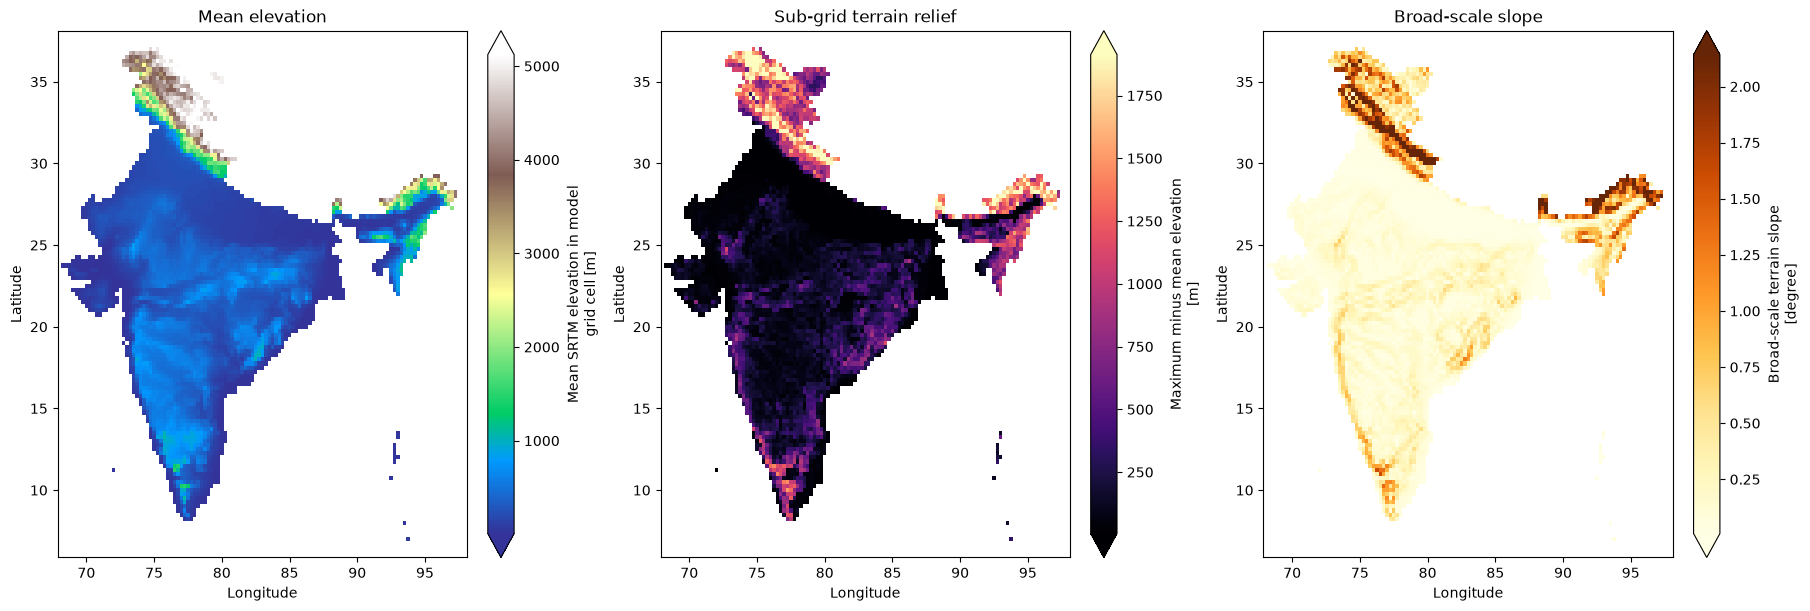

In [19]:
import matplotlib.pyplot as plt

plot_elevation = terrain_ds[
    "elevation_mean_m"
].where(
    terrain_ds["india_grid_mask"] == 1
)

plot_relief = terrain_ds[
    "terrain_relief_m"
].where(
    terrain_ds["india_grid_mask"] == 1
)

plot_slope = terrain_ds[
    "slope_degrees"
].where(
    terrain_ds["india_grid_mask"] == 1
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

plot_elevation.plot(
    ax=axes[0],
    cmap="terrain",
    robust=True,
)
axes[0].set_title("Mean elevation")

plot_relief.plot(
    ax=axes[1],
    cmap="magma",
    robust=True,
)
axes[1].set_title("Sub-grid terrain relief")

plot_slope.plot(
    ax=axes[2],
    cmap="YlOrBr",
    robust=True,
)
axes[2].set_title("Broad-scale slope")

for axis in axes:
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")

plt.show()

In [20]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

COASTLINE_URL = (
    "https://naciscdn.org/naturalearth/"
    "10m/physical/ne_10m_coastline.zip"
)

COASTLINE_ZIP = (
    COAST_DIR /
    "ne_10m_coastline.zip"
)

if not COASTLINE_ZIP.exists():
    print("Downloading Natural Earth coastline...")

    urlretrieve(
        COASTLINE_URL,
        COASTLINE_ZIP,
    )
else:
    print("Coastline ZIP already exists.")

print("Downloaded:", COASTLINE_ZIP.exists())
print("Location:", COASTLINE_ZIP)
print(
    "Size:",
    round(
        COASTLINE_ZIP.stat().st_size
        / (1024 * 1024),
        3,
    ),
    "MB",
)

Coastline ZIP already exists.
Downloaded: True
Location: Z:\Projects\monsoon-postprocessing\data\raw\coastline\ne_10m_coastline.zip
Size: 2.927 MB


In [21]:
COASTLINE_EXTRACT_DIR = (
    COAST_DIR /
    "ne_10m_coastline"
)

COASTLINE_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with ZipFile(COASTLINE_ZIP, "r") as archive:
    archive.extractall(
        COASTLINE_EXTRACT_DIR
    )

coastline_shapefiles = list(
    COASTLINE_EXTRACT_DIR.glob("*.shp")
)

if not coastline_shapefiles:
    raise FileNotFoundError(
        "No coastline shapefile was found."
    )

COASTLINE_FILE = coastline_shapefiles[0]

coastline = gpd.read_file(
    COASTLINE_FILE
)

if coastline.crs is None:
    coastline = coastline.set_crs(
        "EPSG:4326"
    )
else:
    coastline = coastline.to_crs(
        "EPSG:4326"
    )

# Keep coastline segments near the Indian domain.
india_coastline = coastline.cx[
    63.0:103.0,
    1.0:43.0,
].copy()

print("Coastline file:", COASTLINE_FILE)
print("Original coastline segments:", len(coastline))
print("Regional coastline segments:", len(india_coastline))
print("CRS:", india_coastline.crs)
print("Geometry types:")
print(india_coastline.geometry.geom_type.value_counts())

print("\nRegional bounds:")
print(india_coastline.total_bounds)

Coastline file: Z:\Projects\monsoon-postprocessing\data\raw\coastline\ne_10m_coastline\ne_10m_coastline.shp
Original coastline segments: 4133
Regional coastline segments: 299
CRS: EPSG:4326
Geometry types:
LineString    299
Name: count, dtype: int64

Regional bounds:
[ 61.61247806  -5.93043385 109.47242272  25.6256778 ]


In [22]:
from shapely.geometry import Point

INDIA_DISTANCE_CRS = (
    "+proj=lcc "
    "+lat_1=12 "
    "+lat_2=32 "
    "+lat_0=24 "
    "+lon_0=80 "
    "+datum=WGS84 "
    "+units=m "
    "+no_defs"
)

longitude_grid, latitude_grid = np.meshgrid(
    target_longitudes.values,
    target_latitudes.values,
)

grid_points = gpd.GeoDataFrame(
    {
        "grid_id": np.arange(
            longitude_grid.size
        ),
        "latitude": latitude_grid.ravel(),
        "longitude": longitude_grid.ravel(),
    },
    geometry=gpd.points_from_xy(
        longitude_grid.ravel(),
        latitude_grid.ravel(),
    ),
    crs="EPSG:4326",
)

grid_points_projected = (
    grid_points.to_crs(
        INDIA_DISTANCE_CRS
    )
)

coastline_projected = (
    india_coastline.to_crs(
        INDIA_DISTANCE_CRS
    )
)

nearest_coast = gpd.sjoin_nearest(
    grid_points_projected,
    coastline_projected[
        ["geometry"]
    ],
    how="left",
    distance_col="distance_to_coast_m",
)

# Multiple equally close coastline segments may create duplicate matches.
distance_by_grid = (
    nearest_coast
    .groupby(
        "grid_id",
        as_index=True,
    )["distance_to_coast_m"]
    .min()
    .reindex(
        range(longitude_grid.size)
    )
)

distance_to_coast_km = (
    distance_by_grid.values
    .reshape(
        latitude_grid.shape
    )
    / 1000.0
).astype("float32")

print(
    "Distance-grid shape:",
    distance_to_coast_km.shape,
)

print("\nAll-grid distance statistics:")
print(
    "Minimum:",
    float(
        np.nanmin(
            distance_to_coast_km
        )
    ),
    "km",
)
print(
    "Median:",
    float(
        np.nanmedian(
            distance_to_coast_km
        )
    ),
    "km",
)
print(
    "Maximum:",
    float(
        np.nanmax(
            distance_to_coast_km
        )
    ),
    "km",
)

india_distances = (
    distance_to_coast_km[
        india_grid_mask
    ]
)

print("\nIndia-grid distance statistics:")
print(
    "Minimum:",
    float(
        np.nanmin(
            india_distances
        )
    ),
    "km",
)
print(
    "Median:",
    float(
        np.nanmedian(
            india_distances
        )
    ),
    "km",
)
print(
    "Maximum:",
    float(
        np.nanmax(
            india_distances
        )
    ),
    "km",
)

for threshold in [25, 50, 75, 100, 150]:
    cell_count = int(
        (
            india_grid_mask
            & (
                distance_to_coast_km
                <= threshold
            )
        ).sum()
    )

    print(
        f"India cells within "
        f"{threshold} km: "
        f"{cell_count}"
    )

Distance-grid shape: (129, 121)

All-grid distance statistics:
Minimum: 0.004953069146722555 km
Median: 380.7803955078125 km
Maximum: 1870.4873046875 km

India-grid distance statistics:
Minimum: 0.004953069146722555 km
Median: 368.0647277832031 km
Maximum: 1635.0023193359375 km
India cells within 25 km: 237
India cells within 50 km: 426
India cells within 75 km: 602
India cells within 100 km: 770
India cells within 150 km: 1076


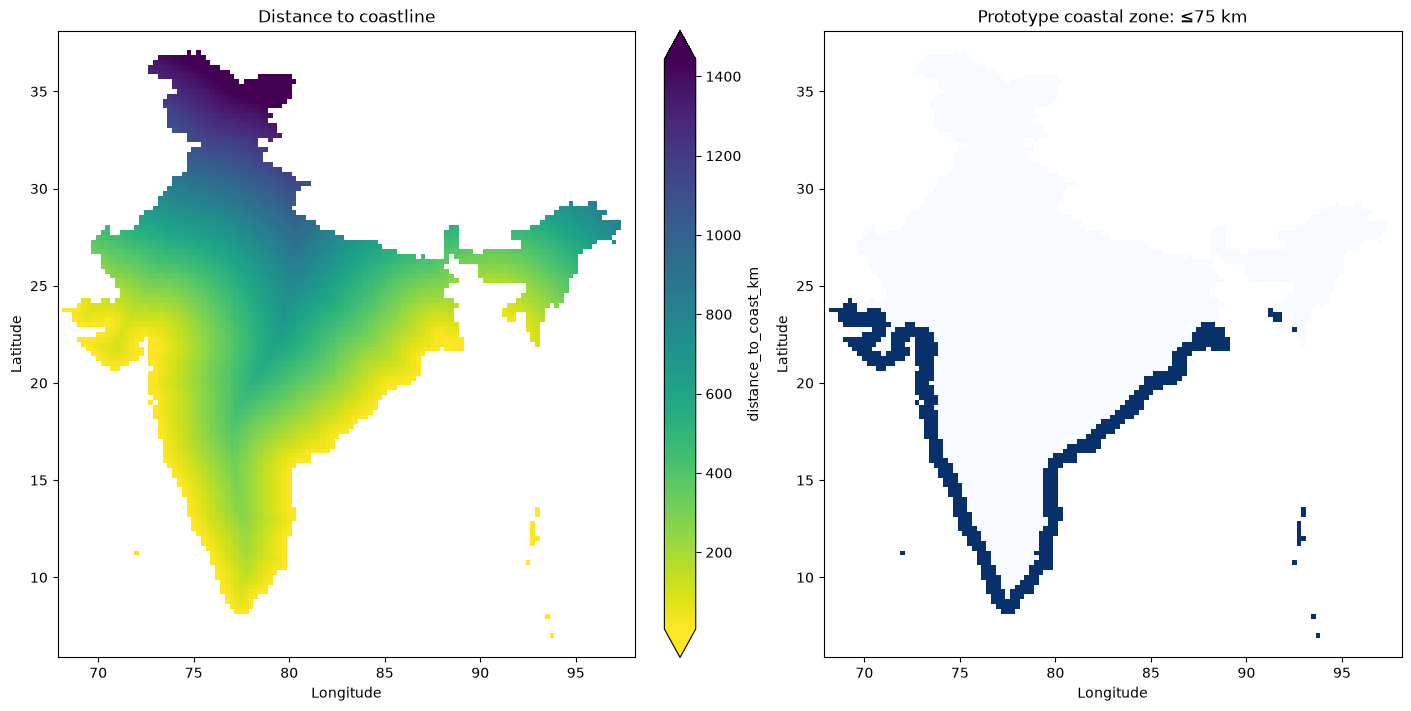

In [23]:
distance_da = xr.DataArray(
    distance_to_coast_km,
    dims=[
        "latitude",
        "longitude",
    ],
    coords={
        "latitude": target_latitudes,
        "longitude": target_longitudes,
    },
    name="distance_to_coast_km",
)

distance_india = distance_da.where(
    india_grid_mask
)

coastal_preview = (
    (distance_da <= 75)
    & india_grid_mask
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    constrained_layout=True,
)

distance_india.plot(
    ax=axes[0],
    cmap="viridis_r",
    robust=True,
)

axes[0].set_title(
    "Distance to coastline"
)

coastal_preview.astype(
    "float32"
).where(
    india_grid_mask
).plot(
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=1,
    add_colorbar=False,
)

axes[1].set_title(
    "Prototype coastal zone: ≤75 km"
)

for axis in axes:
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")

plt.show()

In [24]:
from pathlib import Path

import numpy as np
import xarray as xr

PROJECT_ROOT = Path(r"Z:\Projects\monsoon-postprocessing")

TERRAIN_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "india_terrain_features.nc"
)

GEOGRAPHIC_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "india_geographic_features.nc"
)

terrain_ds = xr.open_dataset(TERRAIN_FILE).load()

distance_candidates = [
    "distance_to_coast_km",
    "distance_grid_km",
    "distance_km_grid",
]

distance_values = None

for variable_name in distance_candidates:
    if variable_name in globals():
        value = globals()[variable_name]

        if isinstance(value, xr.DataArray):
            distance_values = value.values
        else:
            distance_values = np.asarray(value)

        print("Using distance variable:", variable_name)
        break

if distance_values is None:
    raise NameError(
        "Coastline-distance array was not found. "
        "Run the coastline-distance cell first."
    )

distance_values = np.asarray(
    distance_values,
    dtype=np.float32,
)

expected_shape = (
    terrain_ds.sizes["latitude"],
    terrain_ds.sizes["longitude"],
)

if distance_values.shape != expected_shape:
    raise ValueError(
        f"Distance shape {distance_values.shape} "
        f"does not match terrain shape {expected_shape}."
    )

geographic_ds = terrain_ds.copy()

geographic_ds["distance_to_coast_km"] = (
    ("latitude", "longitude"),
    distance_values,
)

land_mask = geographic_ds["india_grid_mask"] == 1

coastal_zone = (
    land_mask
    & (geographic_ds["distance_to_coast_km"] <= 75.0)
)

orographic_zone = (
    land_mask
    & (
        (geographic_ds["elevation_mean_m"] >= 1000.0)
        | (geographic_ds["terrain_relief_m"] >= 500.0)
        | (geographic_ds["slope_degrees"] >= 0.75)
    )
)

coastal_orographic_zone = coastal_zone & orographic_zone

geographic_ds["coastal_zone_75km"] = (
    coastal_zone.astype(np.int8)
)

geographic_ds["orographic_zone"] = (
    orographic_zone.astype(np.int8)
)

geographic_ds["coastal_orographic_zone"] = (
    coastal_orographic_zone.astype(np.int8)
)

regime_code = np.full(
    expected_shape,
    -1,
    dtype=np.int8,
)

land_values = land_mask.values
coastal_values = coastal_zone.values
orographic_values = orographic_zone.values

regime_code[land_values] = 0
regime_code[land_values & coastal_values] = 1
regime_code[land_values & orographic_values] = 2
regime_code[
    land_values
    & coastal_values
    & orographic_values
] = 3

geographic_ds["geographic_regime_code"] = (
    ("latitude", "longitude"),
    regime_code,
)

geographic_ds["distance_to_coast_km"].attrs = {
    "long_name": "Distance to nearest coastline",
    "units": "km",
    "source": "Natural Earth 10m coastline",
}

geographic_ds["coastal_zone_75km"].attrs = {
    "long_name": "Prototype coastal-zone indicator",
    "threshold_km": 75.0,
    "note": "Threshold will be tested through sensitivity analysis",
}

geographic_ds["orographic_zone"].attrs = {
    "long_name": "Prototype orographic-zone indicator",
    "elevation_threshold_m": 1000.0,
    "relief_threshold_m": 500.0,
    "slope_threshold_degrees": 0.75,
}

geographic_ds["geographic_regime_code"].attrs = {
    "long_name": "Prototype geographic regime",
    "codes": (
        "-1=outside India; "
        "0=interior plain; "
        "1=coastal plain; "
        "2=interior orographic; "
        "3=coastal orographic"
    ),
}

geographic_ds.attrs.update(
    {
        "title": "India geographic reliability features",
        "purpose": (
            "Geographic predictors for observation-reliability "
            "and rainfall-correction validation"
        ),
        "coastal_threshold_km": 75.0,
        "classification_status": "Prototype diagnostic features",
    }
)

geographic_ds.to_netcdf(GEOGRAPHIC_FILE)

print("Geographic dataset saved:", GEOGRAPHIC_FILE.exists())
print("Location:", GEOGRAPHIC_FILE)
print(geographic_ds)

Using distance variable: distance_to_coast_km
Geographic dataset saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\india_geographic_features.nc
<xarray.Dataset> Size: 392kB
Dimensions:                  (latitude: 129, longitude: 121)
Coordinates:
  * latitude                 (latitude) float64 1kB 6.0 6.25 6.5 ... 37.75 38.0
  * longitude                (longitude) float64 968B 68.0 68.25 ... 97.75 98.0
Data variables:
    elevation_mean_m         (latitude, longitude) float32 62kB 0.0 ... 4.346...
    elevation_max_m          (latitude, longitude) float32 62kB 0.0 ... 4.677...
    terrain_relief_m         (latitude, longitude) float32 62kB 0.0 ... 330.5
    slope_degrees            (latitude, longitude) float32 62kB 0.0 ... 0.3432
    india_grid_mask          (latitude, longitude) int8 16kB 0 0 0 0 ... 0 0 0 0
    distance_to_coast_km     (latitude, longitude) float32 62kB 532.1 ... 1.7...
    coastal_zone_75km        (latitude, longitude) int8 16kB 0 0 0 0 ... 0

In [25]:
validation_ds = xr.open_dataset(GEOGRAPHIC_FILE)

land = validation_ds["india_grid_mask"] == 1
land_distance = validation_ds[
    "distance_to_coast_km"
].where(land)

assert validation_ds.sizes["latitude"] == 129
assert validation_ds.sizes["longitude"] == 121
assert int(land.sum()) > 0
assert bool(
    np.isfinite(
        land_distance.values[land.values]
    ).all()
)

regime_labels = {
    0: "Interior plain",
    1: "Coastal plain",
    2: "Interior orographic",
    3: "Coastal orographic",
}

regime_rows = []

for code, label in regime_labels.items():
    count = int(
        (
            validation_ds["geographic_regime_code"]
            == code
        ).sum()
    )

    regime_rows.append(
        {
            "code": code,
            "geographic_regime": label,
            "grid_cells": count,
        }
    )

regime_summary = pd.DataFrame(regime_rows)

print("Land cells:", int(land.sum()))
print(
    "Coastal cells:",
    int(validation_ds["coastal_zone_75km"].sum()),
)
print(
    "Orographic cells:",
    int(validation_ds["orographic_zone"].sum()),
)
print(
    "Coastal-orographic cells:",
    int(
        validation_ds[
            "coastal_orographic_zone"
        ].sum()
    ),
)
print(
    "Distance range:",
    float(land_distance.min()),
    "to",
    float(land_distance.max()),
    "km",
)

display(regime_summary)

print("\nStage 3 grid validation passed.")

Land cells: 4655
Coastal cells: 602
Orographic cells: 1047
Coastal-orographic cells: 103
Distance range: 0.004953069146722555 to 1635.0023193359375 km


,code,geographic_regime,grid_cells
0,0,Interior plain,3109
1,1,Coastal plain,499
2,2,Interior orographic,944
3,3,Coastal orographic,103



Stage 3 grid validation passed.


In [26]:
import pandas as pd

LOOKUP_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "complete_grid_district_lookup.csv"
)

DISTRICT_GEOGRAPHIC_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "district_geographic_features.csv"
)

lookup = pd.read_csv(
    LOOKUP_FILE,
    dtype={"shapeID": str},
)

feature_columns = [
    "elevation_mean_m",
    "elevation_max_m",
    "terrain_relief_m",
    "slope_degrees",
    "distance_to_coast_km",
    "india_grid_mask",
    "coastal_zone_75km",
    "orographic_zone",
    "coastal_orographic_zone",
    "geographic_regime_code",
]

grid_features = (
    geographic_ds[feature_columns]
    .to_dataframe()
    .reset_index()
)

lookup["latitude_key"] = lookup["latitude"].round(5)
lookup["longitude_key"] = lookup["longitude"].round(5)

grid_features["latitude_key"] = (
    grid_features["latitude"].round(5)
)
grid_features["longitude_key"] = (
    grid_features["longitude"].round(5)
)

mapped = lookup.merge(
    grid_features.drop(
        columns=["latitude", "longitude"]
    ),
    on=["latitude_key", "longitude_key"],
    how="left",
    validate="many_to_one",
)

missing_features = int(
    mapped["distance_to_coast_km"].isna().sum()
)

print("Mapped records:", len(mapped))
print("Records missing geographic features:", missing_features)
print(
    "Mapped records outside India mask:",
    int((mapped["india_grid_mask"] != 1).sum()),
)

if missing_features:
    raise ValueError(
        "Some district-grid records lack geographic features."
    )

for threshold in [25, 50, 75, 100, 150]:
    mapped[f"coastal_cell_{threshold}km"] = (
        mapped["distance_to_coast_km"] <= threshold
    ).astype(np.int8)

district_geographic = (
    mapped.groupby(
        ["shapeID", "shapeName"],
        as_index=False,
    )
    .agg(
        mapping_method=(
            "mapping_method",
            lambda values: values.mode().iat[0],
        ),
        geographic_grid_cells=(
            "latitude",
            "size",
        ),
        elevation_mean_m=(
            "elevation_mean_m",
            "mean",
        ),
        elevation_max_m=(
            "elevation_max_m",
            "max",
        ),
        terrain_relief_mean_m=(
            "terrain_relief_m",
            "mean",
        ),
        terrain_relief_max_m=(
            "terrain_relief_m",
            "max",
        ),
        slope_mean_degrees=(
            "slope_degrees",
            "mean",
        ),
        slope_max_degrees=(
            "slope_degrees",
            "max",
        ),
        distance_to_coast_min_km=(
            "distance_to_coast_km",
            "min",
        ),
        distance_to_coast_mean_km=(
            "distance_to_coast_km",
            "mean",
        ),
        coastal_fraction_25km=(
            "coastal_cell_25km",
            "mean",
        ),
        coastal_fraction_50km=(
            "coastal_cell_50km",
            "mean",
        ),
        coastal_fraction_75km=(
            "coastal_cell_75km",
            "mean",
        ),
        coastal_fraction_100km=(
            "coastal_cell_100km",
            "mean",
        ),
        coastal_fraction_150km=(
            "coastal_cell_150km",
            "mean",
        ),
        orographic_cell_fraction=(
            "orographic_zone",
            "mean",
        ),
        coastal_orographic_fraction=(
            "coastal_orographic_zone",
            "mean",
        ),
        dominant_geographic_regime_code=(
            "geographic_regime_code",
            lambda values: int(
                values.mode().iat[0]
            ),
        ),
    )
)

district_geographic[
    "coastal_district_75km"
] = (
    district_geographic[
        "distance_to_coast_min_km"
    ] <= 75.0
)

district_geographic[
    "orographic_district"
] = (
    district_geographic[
        "orographic_cell_fraction"
    ] >= 0.25
)

district_geographic[
    "dominant_geographic_regime"
] = (
    district_geographic[
        "dominant_geographic_regime_code"
    ].map(regime_labels)
)

district_geographic.to_csv(
    DISTRICT_GEOGRAPHIC_FILE,
    index=False,
)

print("Saved:", DISTRICT_GEOGRAPHIC_FILE.exists())
print("Location:", DISTRICT_GEOGRAPHIC_FILE)
print("Districts:", district_geographic["shapeID"].nunique())
print("Rows:", len(district_geographic))
print(
    "Coastal districts:",
    int(
        district_geographic[
            "coastal_district_75km"
        ].sum()
    ),
)
print(
    "Orographic districts:",
    int(
        district_geographic[
            "orographic_district"
        ].sum()
    ),
)

display(
    district_geographic.sort_values(
        "distance_to_coast_min_km"
    ).head(20)
)

Mapped records: 4680
Records missing geographic features: 0
Mapped records outside India mask: 0
Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\district_geographic_features.csv
Districts: 735
Rows: 735
Coastal districts: 132
Orographic districts: 204


,shapeID,shapeName,mapping_method,geographic_grid_cells,elevation_mean_m,elevation_max_m,terrain_relief_mean_m,terrain_relief_max_m,slope_mean_degrees,slope_max_degrees,...,coastal_fraction_50km,coastal_fraction_75km,coastal_fraction_100km,coastal_fraction_150km,orographic_cell_fraction,coastal_orographic_fraction,dominant_geographic_regime_code,coastal_district_75km,orographic_district,dominant_geographic_regime
105,76128533B22077262393417,Haora,contained_grid,3,6.942963,17.0,5.723704,6.988889,0.007882,0.014264,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
546,76128533B74859418903113,Thane,contained_grid,5,120.752441,1117.0,638.047546,918.848877,0.397218,0.772428,...,0.800000,1.000000,1.000000,1.000000,0.800000,0.800000,3,True,True,Coastal orographic
488,76128533B67326016655833,Mumbai Suburban,nearest_grid,1,41.965557,391.0,349.034454,349.034454,0.082701,0.082701,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
108,76128533B22587307937261,South Andaman,contained_grid,4,32.422501,379.0,209.577499,332.026672,0.024378,0.040682,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
584,76128533B79180273895456,Uttara Kannada,contained_grid,13,415.256836,957.0,276.897003,541.742249,0.317871,0.580883,...,0.615385,0.923077,1.000000,1.000000,0.230769,0.230769,1,True,False,Coastal plain
411,76128533B59405966069108,Srikakulam,contained_grid,10,92.616776,1321.0,425.083191,1149.215576,0.287899,0.673741,...,0.900000,1.000000,1.000000,1.000000,0.400000,0.400000,1,True,True,Coastal plain
696,76128533B93450974047240,Bhavnagar,contained_grid,11,51.919296,471.0,108.535255,380.888885,0.085193,0.150460,...,0.909091,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
187,76128533B33103505211400,Nicobars,contained_grid,2,45.724445,420.0,256.775574,344.774445,0.029827,0.055571,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
623,76128533B84417945851362,Porbandar,contained_grid,5,34.557110,484.0,121.842896,404.037781,0.091108,0.121121,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain
643,76128533B86430586962522,Viluppuram,contained_grid,6,71.422783,463.0,136.077225,309.517761,0.105554,0.141671,...,0.666667,1.000000,1.000000,1.000000,0.000000,0.000000,1,True,False,Coastal plain


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path(r"Z:\Projects\monsoon-postprocessing")

OBSERVATION_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_imerg_imd_validation.nc"
)

GEOGRAPHIC_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "india_geographic_features.nc"
)

RELIABILITY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_observation_reliability.nc"
)

observation_ds = xr.open_dataset(
    OBSERVATION_FILE
).load()

geographic_ds = xr.open_dataset(
    GEOGRAPHIC_FILE
).load()

np.testing.assert_allclose(
    observation_ds["latitude"],
    geographic_ds["latitude"],
)

np.testing.assert_allclose(
    observation_ds["longitude"],
    geographic_ds["longitude"],
)

geographic_ds = geographic_ds.sel(
    latitude=observation_ds["latitude"],
    longitude=observation_ds["longitude"],
)

raw_valid_mask = (
    observation_ds["common_valid_mask"] == 1
)

india_mask = (
    geographic_ds["india_grid_mask"] == 1
)

analysis_mask = (
    raw_valid_mask
    & india_mask
    & np.isfinite(observation_ds["imerg_rainfall"])
    & np.isfinite(observation_ds["imd_rainfall"])
    & (observation_ds["imerg_rainfall"] >= 0)
    & (observation_ds["imd_rainfall"] >= 0)
)

imerg = observation_ds["imerg_rainfall"].where(
    analysis_mask
)

imd = observation_ds["imd_rainfall"].where(
    analysis_mask
)

difference = imerg - imd
absolute_difference = np.abs(difference)

mean_reference_rainfall = (
    (imerg + imd) / 2.0
)

stabilization_floor_mm = 5.0

normalized_disagreement = (
    absolute_difference
    / (
        stabilization_floor_mm
        + mean_reference_rainfall
    )
)

agreement_score = np.exp(
    -normalized_disagreement
)

print(
    "Original valid IMERG-IMD pairs:",
    int(raw_valid_mask.sum()),
)

print(
    "India analysis pairs:",
    int(analysis_mask.sum()),
)

print(
    "Pairs excluded by geographic mask:",
    int(
        raw_valid_mask.sum()
        - analysis_mask.sum()
    ),
)

print(
    "Analysis date range:",
    str(observation_ds["date"].min().values),
    "to",
    str(observation_ds["date"].max().values),
)

Original valid IMERG-IMD pairs: 153822
India analysis pairs: 143592
Pairs excluded by geographic mask: 10230
Analysis date range: 2018-07-01T00:00:00.000000000 to 2018-07-31T00:00:00.000000000


In [28]:
valid_days = analysis_mask.sum(
    dim="date"
).astype(np.int16)

grid_bias = difference.mean(
    dim="date",
    skipna=True,
)

grid_mae = absolute_difference.mean(
    dim="date",
    skipna=True,
)

grid_rmse = np.sqrt(
    (difference ** 2).mean(
        dim="date",
        skipna=True,
    )
)

grid_correlation = xr.corr(
    imerg,
    imd,
    dim="date",
)

grid_agreement_mean = agreement_score.mean(
    dim="date",
    skipna=True,
)

grid_agreement_median = agreement_score.median(
    dim="date",
    skipna=True,
)

grid_difference_std = difference.std(
    dim="date",
    skipna=True,
)

reliability_ds = xr.Dataset(
    {
        "imerg_rainfall": (
            imerg.astype(np.float32)
        ),
        "imd_rainfall": (
            imd.astype(np.float32)
        ),
        "analysis_mask": (
            analysis_mask.astype(np.int8)
        ),
        "mean_reference_rainfall_mm": (
            mean_reference_rainfall.astype(
                np.float32
            )
        ),
        "observation_difference_mm": (
            difference.astype(np.float32)
        ),
        "absolute_difference_mm": (
            absolute_difference.astype(
                np.float32
            )
        ),
        "normalized_disagreement": (
            normalized_disagreement.astype(
                np.float32
            )
        ),
        "agreement_score": (
            agreement_score.astype(np.float32)
        ),
        "valid_days": valid_days,
        "grid_bias_mm": (
            grid_bias.astype(np.float32)
        ),
        "grid_mae_mm": (
            grid_mae.astype(np.float32)
        ),
        "grid_rmse_mm": (
            grid_rmse.astype(np.float32)
        ),
        "grid_correlation": (
            grid_correlation.astype(np.float32)
        ),
        "grid_agreement_mean": (
            grid_agreement_mean.astype(
                np.float32
            )
        ),
        "grid_agreement_median": (
            grid_agreement_median.astype(
                np.float32
            )
        ),
        "grid_difference_std_mm": (
            grid_difference_std.astype(
                np.float32
            )
        ),
        "geographic_regime_code": (
            geographic_ds[
                "geographic_regime_code"
            ].astype(np.int8)
        ),
        "distance_to_coast_km": (
            geographic_ds[
                "distance_to_coast_km"
            ].astype(np.float32)
        ),
        "elevation_mean_m": (
            geographic_ds[
                "elevation_mean_m"
            ].astype(np.float32)
        ),
        "terrain_relief_m": (
            geographic_ds[
                "terrain_relief_m"
            ].astype(np.float32)
        ),
        "slope_degrees": (
            geographic_ds[
                "slope_degrees"
            ].astype(np.float32)
        ),
    }
)

reliability_ds.attrs = {
    "title": (
        "July 2018 IMERG-IMD observation "
        "reliability analysis"
    ),
    "period": "2018-07-01 to 2018-07-31",
    "agreement_definition": (
        "exp(-absolute_difference / "
        "(5 + mean_IMERG_IMD_rainfall))"
    ),
    "stabilization_floor_mm": 5.0,
    "reference_note": (
        "IMERG and IMD are treated as independent "
        "observation products; neither is assumed "
        "to be error-free ground truth."
    ),
    "purpose": (
        "RAIN-Trust observation-confidence analysis"
    ),
}

reliability_ds.to_netcdf(
    RELIABILITY_FILE
)

saved_ds = xr.open_dataset(
    RELIABILITY_FILE
)

required_variables = [
    "agreement_score",
    "grid_bias_mm",
    "grid_mae_mm",
    "grid_rmse_mm",
    "grid_correlation",
    "distance_to_coast_km",
    "elevation_mean_m",
]

required_available = all(
    variable in saved_ds
    for variable in required_variables
)

print("Saved:", RELIABILITY_FILE.exists())
print("Location:", RELIABILITY_FILE)
print("Required variables available:", required_available)
print(saved_ds)

D:\condaenv\envs\monsoon\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\condaenv\envs\monsoon\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\condaenv\envs\monsoon\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\july2018_observation_reliability.nc
Required variables available: True
<xarray.Dataset> Size: 15MB
Dimensions:                     (date: 31, latitude: 129, longitude: 121)
Coordinates:
  * date                        (date) datetime64[ns] 248B 2018-07-01 ... 201...
  * latitude                    (latitude) float64 1kB 6.0 6.25 ... 37.75 38.0
  * longitude                   (longitude) float64 968B 68.0 68.25 ... 98.0
Data variables: (12/21)
    imerg_rainfall              (date, latitude, longitude) float32 2MB ...
    imd_rainfall                (date, latitude, longitude) float32 2MB ...
    analysis_mask               (date, latitude, longitude) int8 484kB ...
    mean_reference_rainfall_mm  (date, latitude, longitude) float32 2MB ...
    observation_difference_mm   (date, latitude, longitude) float32 2MB ...
    absolute_difference_mm      (date, latitude, longitude) float32 2MB ...
    ...                   

In [29]:
DAILY_REGIME_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_reliability_daily_regime.csv"
)

REGIME_SUMMARY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_reliability_regime_summary.csv"
)

regime_labels = {
    0: "Interior plain",
    1: "Coastal plain",
    2: "Interior orographic",
    3: "Coastal orographic",
}

analysis_table = (
    reliability_ds[
        [
            "imerg_rainfall",
            "imd_rainfall",
            "analysis_mask",
            "mean_reference_rainfall_mm",
            "observation_difference_mm",
            "absolute_difference_mm",
            "agreement_score",
            "geographic_regime_code",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

analysis_table = analysis_table[
    analysis_table["analysis_mask"] == 1
].copy()

analysis_table[
    "geographic_regime"
] = analysis_table[
    "geographic_regime_code"
].map(regime_labels)

def calculate_group_metrics(group):
    imerg_values = group[
        "imerg_rainfall"
    ].to_numpy()

    imd_values = group[
        "imd_rainfall"
    ].to_numpy()

    differences = group[
        "observation_difference_mm"
    ].to_numpy()

    absolute_differences = group[
        "absolute_difference_mm"
    ].to_numpy()

    if (
        len(group) > 1
        and np.std(imerg_values) > 0
        and np.std(imd_values) > 0
    ):
        correlation = np.corrcoef(
            imerg_values,
            imd_values,
        )[0, 1]
    else:
        correlation = np.nan

    return pd.Series(
        {
            "valid_pairs": len(group),
            "mean_rainfall_mm": group[
                "mean_reference_rainfall_mm"
            ].mean(),
            "bias_mm": differences.mean(),
            "mae_mm": absolute_differences.mean(),
            "rmse_mm": np.sqrt(
                np.mean(differences ** 2)
            ),
            "correlation": correlation,
            "agreement_score": group[
                "agreement_score"
            ].mean(),
        }
    )

daily_regime_metrics = (
    analysis_table.groupby(
        [
            "date",
            "geographic_regime_code",
            "geographic_regime",
        ],
        observed=True,
    )
    .apply(
        calculate_group_metrics,
        include_groups=False,
    )
    .reset_index()
)

regime_summary = (
    daily_regime_metrics.groupby(
        [
            "geographic_regime_code",
            "geographic_regime",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        dates=("date", "nunique"),
        mean_daily_valid_pairs=(
            "valid_pairs",
            "mean",
        ),
        mean_rainfall_mm=(
            "mean_rainfall_mm",
            "mean",
        ),
        mean_bias_mm=(
            "bias_mm",
            "mean",
        ),
        mean_mae_mm=(
            "mae_mm",
            "mean",
        ),
        mean_rmse_mm=(
            "rmse_mm",
            "mean",
        ),
        mean_spatial_correlation=(
            "correlation",
            "mean",
        ),
        mean_agreement_score=(
            "agreement_score",
            "mean",
        ),
    )
)

daily_regime_metrics.to_csv(
    DAILY_REGIME_FILE,
    index=False,
)

regime_summary.to_csv(
    REGIME_SUMMARY_FILE,
    index=False,
)

print("Daily-regime rows:", len(daily_regime_metrics))
print("Daily metrics saved:", DAILY_REGIME_FILE.exists())
print("Summary saved:", REGIME_SUMMARY_FILE.exists())

display(regime_summary)

print("\nStage 4A completed.")

Daily-regime rows: 124
Daily metrics saved: True
Summary saved: True


,geographic_regime_code,geographic_regime,dates,mean_daily_valid_pairs,mean_rainfall_mm,mean_bias_mm,mean_mae_mm,mean_rmse_mm,mean_spatial_correlation,mean_agreement_score
0,0,Interior plain,31,3108.0,8.306244,1.308416,9.346192,17.578703,0.325380,0.679982
1,1,Coastal plain,31,479.0,13.084135,-0.256122,12.655142,22.437739,0.478370,0.660992
2,2,Interior orographic,31,943.0,8.186892,-0.392081,9.222632,16.955877,0.324795,0.665607
3,3,Coastal orographic,31,102.0,21.560117,-7.143516,19.513555,28.611027,0.383068,0.587105



Stage 4A completed.


In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"Z:\Projects\monsoon-postprocessing"
)

DAILY_REGIME_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_reliability_daily_regime.csv"
)

BOOTSTRAP_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_reliability_bootstrap.csv"
)

daily_metrics = pd.read_csv(
    DAILY_REGIME_FILE,
    parse_dates=["date"],
)

regime_labels = {
    0: "Interior plain",
    1: "Coastal plain",
    2: "Interior orographic",
    3: "Coastal orographic",
}

metric_columns = [
    "bias_mm",
    "mae_mm",
    "rmse_mm",
    "correlation",
    "agreement_score",
]

dates = np.sort(
    daily_metrics["date"].unique()
)

bootstrap_iterations = 2000
rng = np.random.default_rng(42)

bootstrap_indices = rng.integers(
    0,
    len(dates),
    size=(bootstrap_iterations, len(dates)),
)

bootstrap_rows = []

for metric in metric_columns:
    regime_bootstraps = {}

    for regime_code in regime_labels:
        regime_values = (
            daily_metrics[
                daily_metrics[
                    "geographic_regime_code"
                ] == regime_code
            ]
            .set_index("date")[metric]
            .reindex(dates)
            .to_numpy(dtype=float)
        )

        sampled_values = regime_values[
            bootstrap_indices
        ]

        bootstrap_means = np.nanmean(
            sampled_values,
            axis=1,
        )

        regime_bootstraps[
            regime_code
        ] = bootstrap_means

    baseline_bootstrap = regime_bootstraps[0]

    for regime_code, regime_name in (
        regime_labels.items()
    ):
        regime_values = (
            daily_metrics[
                daily_metrics[
                    "geographic_regime_code"
                ] == regime_code
            ]
            .set_index("date")[metric]
            .reindex(dates)
            .to_numpy(dtype=float)
        )

        bootstrap_means = regime_bootstraps[
            regime_code
        ]

        difference_bootstrap = (
            bootstrap_means
            - baseline_bootstrap
        )

        estimate = np.nanmean(regime_values)

        confidence_low, confidence_high = (
            np.nanpercentile(
                bootstrap_means,
                [2.5, 97.5],
            )
        )

        difference_estimate = (
            estimate
            - np.nanmean(
                daily_metrics[
                    daily_metrics[
                        "geographic_regime_code"
                    ] == 0
                ][metric]
            )
        )

        difference_low, difference_high = (
            np.nanpercentile(
                difference_bootstrap,
                [2.5, 97.5],
            )
        )

        supported_difference = (
            regime_code != 0
            and (
                difference_low > 0
                or difference_high < 0
            )
        )

        bootstrap_rows.append(
            {
                "metric": metric,
                "geographic_regime_code": (
                    regime_code
                ),
                "geographic_regime": (
                    regime_name
                ),
                "estimate": estimate,
                "ci_2_5": confidence_low,
                "ci_97_5": confidence_high,
                "difference_vs_interior_plain": (
                    difference_estimate
                ),
                "difference_ci_2_5": (
                    difference_low
                ),
                "difference_ci_97_5": (
                    difference_high
                ),
                "difference_supported": (
                    supported_difference
                ),
            }
        )

bootstrap_summary = pd.DataFrame(
    bootstrap_rows
)

bootstrap_summary.to_csv(
    BOOTSTRAP_FILE,
    index=False,
)

print("Bootstrap iterations:", bootstrap_iterations)
print("Dates resampled:", len(dates))
print("Saved:", BOOTSTRAP_FILE.exists())
print("Location:", BOOTSTRAP_FILE)

display(
    bootstrap_summary[
        bootstrap_summary[
            "geographic_regime_code"
        ] != 0
    ].round(4)
)

Bootstrap iterations: 2000
Dates resampled: 31
Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\observation_reliability_bootstrap.csv


,metric,geographic_regime_code,geographic_regime,estimate,ci_2_5,ci_97_5,difference_vs_interior_plain,difference_ci_2_5,difference_ci_97_5,difference_supported
1,bias_mm,1,Coastal plain,-0.2561,-2.5684,1.7880,-1.5645,-3.6201,0.3441,False
2,bias_mm,2,Interior orographic,-0.3921,-1.5338,0.6878,-1.7005,-2.9019,-0.5438,True
3,bias_mm,3,Coastal orographic,-7.1435,-10.9999,-3.4401,-8.4519,-12.2280,-4.6206,True
5,mae_mm,1,Coastal plain,12.6551,10.7853,14.5464,3.3089,1.7297,4.9045,True
6,mae_mm,2,Interior orographic,9.2226,8.3977,10.0364,-0.1236,-1.0758,0.8595,False
7,mae_mm,3,Coastal orographic,19.5136,16.5914,22.6116,10.1674,7.5351,12.9474,True
9,rmse_mm,1,Coastal plain,22.4377,19.5132,25.4499,4.8590,2.0987,7.7221,True
10,rmse_mm,2,Interior orographic,16.9559,15.4722,18.4509,-0.6228,-2.2923,1.1356,False
11,rmse_mm,3,Coastal orographic,28.6110,24.6043,32.7908,11.0323,7.1331,15.0606,True
13,correlation,1,Coastal plain,0.4784,0.4129,0.5377,0.1530,0.0732,0.2313,True


In [31]:
import xarray as xr

RELIABILITY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_observation_reliability.nc"
)

reliability_ds = xr.open_dataset(
    RELIABILITY_FILE
)

model_columns = [
    "imerg_rainfall",
    "agreement_score",
    "analysis_mask",
    "geographic_regime_code",
    "distance_to_coast_km",
    "elevation_mean_m",
    "terrain_relief_m",
    "slope_degrees",
]

model_table = (
    reliability_ds[model_columns]
    .to_dataframe()
    .reset_index()
)

model_table = model_table[
    model_table["analysis_mask"] == 1
].copy()

required_columns = [
    "imerg_rainfall",
    "agreement_score",
    "distance_to_coast_km",
    "elevation_mean_m",
    "terrain_relief_m",
    "slope_degrees",
    "geographic_regime_code",
]

model_table = model_table.dropna(
    subset=required_columns
)

model_table[
    "log_imerg_rainfall"
] = np.log1p(
    model_table["imerg_rainfall"]
)

model_table[
    "log_distance_to_coast"
] = np.log1p(
    model_table["distance_to_coast_km"]
)

model_table[
    "log_elevation"
] = np.log1p(
    model_table[
        "elevation_mean_m"
    ].clip(lower=0)
)

model_table[
    "log_terrain_relief"
] = np.log1p(
    model_table[
        "terrain_relief_m"
    ].clip(lower=0)
)

model_table["date_group"] = (
    pd.to_datetime(model_table["date"])
    .dt.strftime("%Y-%m-%d")
)

print("Model records:", len(model_table))
print(
    "Dates:",
    model_table["date_group"].nunique(),
)
print(
    "Grid cells:",
    model_table[
        ["latitude", "longitude"]
    ].drop_duplicates().shape[0],
)
print(
    "Agreement range:",
    model_table["agreement_score"].min(),
    "to",
    model_table["agreement_score"].max(),
)

display(
    model_table[
        required_columns
    ].describe().T
)

Model records: 143592
Dates: 31
Grid cells: 4632
Agreement range: 0.15182264 to 1.0


,count,mean,std,min,25%,50%,75%,max
imerg_rainfall,143592.0,9.375050,16.300037,0.000000,0.202500,2.335000,11.199062,210.675003
agreement_score,143592.0,0.673046,0.260991,0.151823,0.438818,0.703437,0.928537,1.000000
distance_to_coast_km,143592.0,465.631195,380.839966,0.004953,168.390564,369.398834,659.951157,1635.002319
elevation_mean_m,143592.0,739.086975,1230.177979,0.072222,155.213329,321.373901,578.761642,5782.222168
terrain_relief_m,143592.0,350.188965,491.940308,2.336667,44.257504,140.844452,415.639450,3620.828857
slope_degrees,143592.0,0.328030,0.523988,0.000348,0.058251,0.131851,0.324296,4.332751
geographic_regime_code,143592.0,0.576641,0.885112,0.000000,0.000000,0.000000,1.000000,3.000000


In [32]:
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold

PREDICTION_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_confidence_oof_predictions.csv.gz"
)

MODEL_METRICS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_confidence_model_metrics.csv"
)

baseline_features = [
    "log_imerg_rainfall",
]

geographic_features = [
    "log_imerg_rainfall",
    "log_distance_to_coast",
    "log_elevation",
    "log_terrain_relief",
    "slope_degrees",
]

target_column = "agreement_score"

groups = model_table[
    "date_group"
].to_numpy()

target = model_table[
    target_column
].to_numpy()

group_cv = GroupKFold(
    n_splits=5
)

baseline_predictions = np.full(
    len(model_table),
    np.nan,
)

geographic_predictions = np.full(
    len(model_table),
    np.nan,
)

fold_assignments = np.full(
    len(model_table),
    -1,
    dtype=np.int8,
)

metric_rows = []

for fold, (train_index, test_index) in enumerate(
    group_cv.split(
        model_table,
        target,
        groups,
    ),
    start=1,
):
    training_regimes = model_table.iloc[
        train_index
    ]["geographic_regime_code"]

    regime_counts = (
        training_regimes.value_counts()
    )

    training_weights = (
        training_regimes.map(
            lambda code: 1.0
            / regime_counts.loc[code]
        )
        .to_numpy()
    )

    training_weights = (
        training_weights
        / training_weights.mean()
    )

    baseline_model = (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=150,
            max_leaf_nodes=15,
            min_samples_leaf=100,
            l2_regularization=1.0,
            random_state=42,
        )
    )

    geographic_model = (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=150,
            max_leaf_nodes=15,
            min_samples_leaf=100,
            l2_regularization=1.0,
            random_state=42,
        )
    )

    baseline_model.fit(
        model_table.iloc[
            train_index
        ][baseline_features],
        target[train_index],
        sample_weight=training_weights,
    )

    geographic_model.fit(
        model_table.iloc[
            train_index
        ][geographic_features],
        target[train_index],
        sample_weight=training_weights,
    )

    baseline_fold_prediction = np.clip(
        baseline_model.predict(
            model_table.iloc[
                test_index
            ][baseline_features]
        ),
        0,
        1,
    )

    geographic_fold_prediction = np.clip(
        geographic_model.predict(
            model_table.iloc[
                test_index
            ][geographic_features]
        ),
        0,
        1,
    )

    baseline_predictions[
        test_index
    ] = baseline_fold_prediction

    geographic_predictions[
        test_index
    ] = geographic_fold_prediction

    fold_assignments[
        test_index
    ] = fold

    for model_name, prediction in [
        (
            "IMERG-intensity baseline",
            baseline_fold_prediction,
        ),
        (
            "IMERG + geographic features",
            geographic_fold_prediction,
        ),
    ]:
        observed = target[test_index]

        regime_mae = []

        test_regimes = model_table.iloc[
            test_index
        ]["geographic_regime_code"].to_numpy()

        for regime_code in np.unique(
            test_regimes
        ):
            regime_mask = (
                test_regimes == regime_code
            )

            regime_mae.append(
                mean_absolute_error(
                    observed[regime_mask],
                    prediction[regime_mask],
                )
            )

        metric_rows.append(
            {
                "fold": fold,
                "model": model_name,
                "test_dates": (
                    model_table.iloc[
                        test_index
                    ]["date_group"].nunique()
                ),
                "test_records": len(test_index),
                "MAE": mean_absolute_error(
                    observed,
                    prediction,
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        observed,
                        prediction,
                    )
                ),
                "R2": r2_score(
                    observed,
                    prediction,
                ),
                "macro_regime_MAE": (
                    np.mean(regime_mae)
                ),
            }
        )

model_table[
    "baseline_agreement_prediction"
] = baseline_predictions

model_table[
    "geographic_agreement_prediction"
] = geographic_predictions

model_table[
    "cv_fold"
] = fold_assignments

model_metrics = pd.DataFrame(
    metric_rows
)

model_summary = (
    model_metrics.groupby(
        "model",
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_R2=("R2", "mean"),
        mean_macro_regime_MAE=(
            "macro_regime_MAE",
            "mean",
        ),
    )
)

prediction_columns = [
    "date",
    "latitude",
    "longitude",
    "geographic_regime_code",
    "agreement_score",
    "baseline_agreement_prediction",
    "geographic_agreement_prediction",
    "cv_fold",
]

model_table[
    prediction_columns
].to_csv(
    PREDICTION_FILE,
    index=False,
    compression="gzip",
)

model_metrics.to_csv(
    MODEL_METRICS_FILE,
    index=False,
)

print("All predictions available:", bool(
    np.isfinite(
        geographic_predictions
    ).all()
))

print("Prediction file saved:", PREDICTION_FILE.exists())
print("Metrics saved:", MODEL_METRICS_FILE.exists())

display(model_summary.round(5))

baseline_row = model_summary[
    model_summary["model"]
    == "IMERG-intensity baseline"
].iloc[0]

geographic_row = model_summary[
    model_summary["model"]
    == "IMERG + geographic features"
].iloc[0]

comparison = pd.DataFrame(
    {
        "metric": [
            "MAE reduction",
            "RMSE reduction",
            "R2 improvement",
            "Macro-regime MAE reduction",
        ],
        "value": [
            baseline_row["mean_MAE"]
            - geographic_row["mean_MAE"],
            baseline_row["mean_RMSE"]
            - geographic_row["mean_RMSE"],
            geographic_row["mean_R2"]
            - baseline_row["mean_R2"],
            baseline_row[
                "mean_macro_regime_MAE"
            ]
            - geographic_row[
                "mean_macro_regime_MAE"
            ],
        ],
    }
)

display(comparison.round(6))

All predictions available: True
Prediction file saved: True
Metrics saved: True


,model,folds,mean_MAE,mean_RMSE,mean_R2,mean_macro_regime_MAE
0,IMERG + geographic features,5,0.16514,0.20731,0.36846,0.16639
1,IMERG-intensity baseline,5,0.17594,0.21282,0.33458,0.18196


,metric,value
0,MAE reduction,0.010799
1,RMSE reduction,0.005513
2,R2 improvement,0.033882
3,Macro-regime MAE reduction,0.015569


In [33]:
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold

SPATIAL_METRICS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_confidence_spatial_cv_metrics.csv"
)

SPATIAL_PREDICTION_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_confidence_spatial_predictions.csv.gz"
)

baseline_features = [
    "log_imerg_rainfall",
]

geographic_features = [
    "log_imerg_rainfall",
    "log_distance_to_coast",
    "log_elevation",
    "log_terrain_relief",
    "slope_degrees",
]

model_table["latitude_block"] = np.floor(
    (
        model_table["latitude"]
        - model_table["latitude"].min()
    ) / 5.0
).astype(int)

model_table["longitude_block"] = np.floor(
    (
        model_table["longitude"]
        - model_table["longitude"].min()
    ) / 5.0
).astype(int)

model_table["spatial_block"] = (
    model_table["latitude_block"].astype(str)
    + "_"
    + model_table["longitude_block"].astype(str)
)

spatial_groups = model_table[
    "spatial_block"
].to_numpy()

target = model_table[
    "agreement_score"
].to_numpy()

spatial_cv = GroupKFold(
    n_splits=5
)

baseline_spatial_predictions = np.full(
    len(model_table),
    np.nan,
)

geographic_spatial_predictions = np.full(
    len(model_table),
    np.nan,
)

spatial_fold_assignments = np.full(
    len(model_table),
    -1,
    dtype=np.int8,
)

spatial_metric_rows = []

for fold, (train_index, test_index) in enumerate(
    spatial_cv.split(
        model_table,
        target,
        spatial_groups,
    ),
    start=1,
):
    training_regimes = model_table.iloc[
        train_index
    ]["geographic_regime_code"]

    regime_counts = (
        training_regimes.value_counts()
    )

    training_weights = (
        training_regimes.map(
            lambda code: 1.0
            / regime_counts.loc[code]
        )
        .to_numpy()
    )

    training_weights = (
        training_weights
        / training_weights.mean()
    )

    baseline_model = (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=150,
            max_leaf_nodes=15,
            min_samples_leaf=100,
            l2_regularization=1.0,
            random_state=42,
        )
    )

    geographic_model = (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=150,
            max_leaf_nodes=15,
            min_samples_leaf=100,
            l2_regularization=1.0,
            random_state=42,
        )
    )

    baseline_model.fit(
        model_table.iloc[
            train_index
        ][baseline_features],
        target[train_index],
        sample_weight=training_weights,
    )

    geographic_model.fit(
        model_table.iloc[
            train_index
        ][geographic_features],
        target[train_index],
        sample_weight=training_weights,
    )

    baseline_prediction = np.clip(
        baseline_model.predict(
            model_table.iloc[
                test_index
            ][baseline_features]
        ),
        0,
        1,
    )

    geographic_prediction = np.clip(
        geographic_model.predict(
            model_table.iloc[
                test_index
            ][geographic_features]
        ),
        0,
        1,
    )

    baseline_spatial_predictions[
        test_index
    ] = baseline_prediction

    geographic_spatial_predictions[
        test_index
    ] = geographic_prediction

    spatial_fold_assignments[
        test_index
    ] = fold

    observed = target[test_index]

    for model_name, prediction in [
        (
            "IMERG-intensity baseline",
            baseline_prediction,
        ),
        (
            "IMERG + geographic features",
            geographic_prediction,
        ),
    ]:
        test_regimes = model_table.iloc[
            test_index
        ]["geographic_regime_code"].to_numpy()

        regime_mae = []

        for regime_code in np.unique(
            test_regimes
        ):
            regime_mask = (
                test_regimes == regime_code
            )

            regime_mae.append(
                mean_absolute_error(
                    observed[regime_mask],
                    prediction[regime_mask],
                )
            )

        spatial_metric_rows.append(
            {
                "fold": fold,
                "model": model_name,
                "test_blocks": (
                    model_table.iloc[
                        test_index
                    ]["spatial_block"].nunique()
                ),
                "test_records": len(test_index),
                "MAE": mean_absolute_error(
                    observed,
                    prediction,
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        observed,
                        prediction,
                    )
                ),
                "R2": r2_score(
                    observed,
                    prediction,
                ),
                "macro_regime_MAE": (
                    np.mean(regime_mae)
                ),
            }
        )

spatial_metrics = pd.DataFrame(
    spatial_metric_rows
)

spatial_summary = (
    spatial_metrics.groupby(
        "model",
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_R2=("R2", "mean"),
        mean_macro_regime_MAE=(
            "macro_regime_MAE",
            "mean",
        ),
    )
)

model_table[
    "baseline_spatial_prediction"
] = baseline_spatial_predictions

model_table[
    "geographic_spatial_prediction"
] = geographic_spatial_predictions

model_table[
    "spatial_cv_fold"
] = spatial_fold_assignments

spatial_metrics.to_csv(
    SPATIAL_METRICS_FILE,
    index=False,
)

model_table[
    [
        "date",
        "latitude",
        "longitude",
        "spatial_block",
        "geographic_regime_code",
        "agreement_score",
        "baseline_spatial_prediction",
        "geographic_spatial_prediction",
        "spatial_cv_fold",
    ]
].to_csv(
    SPATIAL_PREDICTION_FILE,
    index=False,
    compression="gzip",
)

print(
    "Spatial blocks:",
    model_table["spatial_block"].nunique(),
)

print(
    "All spatial predictions available:",
    bool(
        np.isfinite(
            geographic_spatial_predictions
        ).all()
    ),
)

print(
    "Metrics saved:",
    SPATIAL_METRICS_FILE.exists(),
)

display(spatial_summary.round(5))

spatial_baseline = spatial_summary[
    spatial_summary["model"]
    == "IMERG-intensity baseline"
].iloc[0]

spatial_geographic = spatial_summary[
    spatial_summary["model"]
    == "IMERG + geographic features"
].iloc[0]

spatial_comparison = pd.DataFrame(
    {
        "metric": [
            "MAE reduction",
            "RMSE reduction",
            "R2 improvement",
            "Macro-regime MAE reduction",
        ],
        "value": [
            spatial_baseline["mean_MAE"]
            - spatial_geographic["mean_MAE"],
            spatial_baseline["mean_RMSE"]
            - spatial_geographic["mean_RMSE"],
            spatial_geographic["mean_R2"]
            - spatial_baseline["mean_R2"],
            spatial_baseline[
                "mean_macro_regime_MAE"
            ]
            - spatial_geographic[
                "mean_macro_regime_MAE"
            ],
        ],
    }
)

display(spatial_comparison.round(6))

Spatial blocks: 23
All spatial predictions available: True
Metrics saved: True


,model,folds,mean_MAE,mean_RMSE,mean_R2,mean_macro_regime_MAE
0,IMERG + geographic features,5,0.16803,0.21056,0.34375,0.17054
1,IMERG-intensity baseline,5,0.17596,0.21272,0.33013,0.17703


,metric,value
0,MAE reduction,0.007929
1,RMSE reduction,0.002159
2,R2 improvement,0.013619
3,Macro-regime MAE reduction,0.006487


In [34]:
SENSITIVITY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_agreement_sensitivity.csv"
)

sensitivity_table = (
    reliability_ds[
        [
            "analysis_mask",
            "absolute_difference_mm",
            "mean_reference_rainfall_mm",
            "geographic_regime_code",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

sensitivity_table = sensitivity_table[
    sensitivity_table["analysis_mask"] == 1
].dropna(
    subset=[
        "absolute_difference_mm",
        "mean_reference_rainfall_mm",
        "geographic_regime_code",
    ]
)

regime_labels = {
    0: "Interior plain",
    1: "Coastal plain",
    2: "Interior orographic",
    3: "Coastal orographic",
}

sensitivity_rows = []

for floor_mm in [2.0, 5.0, 10.0]:
    working_table = sensitivity_table.copy()

    working_table["agreement_score"] = np.exp(
        -working_table[
            "absolute_difference_mm"
        ]
        / (
            floor_mm
            + working_table[
                "mean_reference_rainfall_mm"
            ]
        )
    )

    daily_scores = (
        working_table.groupby(
            [
                "date",
                "geographic_regime_code",
            ],
            as_index=False,
        )["agreement_score"]
        .mean()
    )

    regime_scores = (
        daily_scores.groupby(
            "geographic_regime_code",
            as_index=False,
        )
        .agg(
            dates=("date", "nunique"),
            mean_agreement_score=(
                "agreement_score",
                "mean",
            ),
            daily_score_std=(
                "agreement_score",
                "std",
            ),
        )
    )

    regime_scores[
        "stabilization_floor_mm"
    ] = floor_mm

    regime_scores[
        "geographic_regime"
    ] = regime_scores[
        "geographic_regime_code"
    ].map(regime_labels)

    regime_scores[
        "agreement_rank"
    ] = regime_scores[
        "mean_agreement_score"
    ].rank(
        ascending=False,
        method="min",
    ).astype(int)

    interior_score = regime_scores.loc[
        regime_scores[
            "geographic_regime_code"
        ] == 0,
        "mean_agreement_score",
    ].iloc[0]

    regime_scores[
        "difference_vs_interior_plain"
    ] = (
        regime_scores[
            "mean_agreement_score"
        ]
        - interior_score
    )

    sensitivity_rows.append(
        regime_scores
    )

sensitivity_summary = pd.concat(
    sensitivity_rows,
    ignore_index=True,
)

sensitivity_summary = sensitivity_summary[
    [
        "stabilization_floor_mm",
        "geographic_regime_code",
        "geographic_regime",
        "dates",
        "mean_agreement_score",
        "daily_score_std",
        "agreement_rank",
        "difference_vs_interior_plain",
    ]
]

sensitivity_summary.to_csv(
    SENSITIVITY_FILE,
    index=False,
)

print("Saved:", SENSITIVITY_FILE.exists())

display(
    sensitivity_summary.round(5)
)

Saved: True


,stabilization_floor_mm,geographic_regime_code,geographic_regime,dates,mean_agreement_score,daily_score_std,agreement_rank,difference_vs_interior_plain
0,2.0,0,Interior plain,31,0.60204,0.06838,1,0.00000
1,2.0,1,Coastal plain,31,0.58532,0.07184,2,-0.01672
2,2.0,2,Interior orographic,31,0.57587,0.04868,3,-0.02617
3,2.0,3,Coastal orographic,31,0.51970,0.05780,4,-0.08234
4,5.0,0,Interior plain,31,0.67998,0.06063,1,0.00000
5,5.0,1,Coastal plain,31,0.66099,0.07035,3,-0.01899
6,5.0,2,Interior orographic,31,0.66561,0.04649,2,-0.01437
7,5.0,3,Coastal orographic,31,0.58710,0.06398,4,-0.09288
8,10.0,0,Interior plain,31,0.74540,0.05141,1,0.00000
9,10.0,1,Coastal plain,31,0.72471,0.06573,3,-0.02068


In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path(
    r"Z:\Projects\monsoon-postprocessing"
)

CORRECTION_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_regime_correction_predictions.nc"
)

RELIABILITY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_observation_reliability.nc"
)

PREDICTION_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "observation_confidence_oof_predictions.csv.gz"
)

TRUST_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_trust_weighted_corrections.nc"
)

correction_ds = xr.open_dataset(
    CORRECTION_FILE
).load()

reliability_ds = xr.open_dataset(
    RELIABILITY_FILE
).load()

confidence_predictions = pd.read_csv(
    PREDICTION_FILE,
    parse_dates=["date"],
)

duplicate_keys = confidence_predictions.duplicated(
    subset=[
        "date",
        "latitude",
        "longitude",
    ]
).sum()

if duplicate_keys:
    raise ValueError(
        f"Duplicate confidence records: {duplicate_keys}"
    )

confidence_grid = (
    confidence_predictions.set_index(
        [
            "date",
            "latitude",
            "longitude",
        ]
    )[
        "geographic_agreement_prediction"
    ]
    .to_xarray()
    .reindex(
        date=correction_ds["date"],
        latitude=correction_ds["latitude"],
        longitude=correction_ds["longitude"],
    )
)

confidence_available = np.isfinite(
    confidence_grid
)

median_confidence = float(
    confidence_predictions[
        "geographic_agreement_prediction"
    ].median()
)

confidence_filled = (
    confidence_grid
    .fillna(median_confidence)
    .clip(0, 1)
)

print(
    "Correction dates:",
    correction_ds.sizes["date"],
)

print(
    "Available confidence values:",
    int(confidence_available.sum()),
)

print(
    "Missing confidence values:",
    int((~confidence_available).sum()),
)

print(
    "Median fallback confidence:",
    median_confidence,
)

print(
    "Confidence range:",
    float(confidence_filled.min()),
    "to",
    float(confidence_filled.max()),
)

Correction dates: 31
Available confidence values: 143592
Missing confidence values: 340287
Median fallback confidence: 0.648307310521
Confidence range: 0.3057926048177154 to 0.9994576892004196


In [36]:
raw_forecast = correction_ds[
    "raw_gefs_rainfall"
]

global_forecast = correction_ds[
    "global_corrected_rainfall"
]

regime_forecast = correction_ds[
    "regime_corrected_rainfall"
]

trust_raw_blend = (
    raw_forecast
    + confidence_filled
    * (
        regime_forecast
        - raw_forecast
    )
).clip(min=0)

trust_global_blend = (
    global_forecast
    + confidence_filled
    * (
        regime_forecast
        - global_forecast
    )
).clip(min=0)

trust_ds = xr.Dataset(
    {
        "raw_gefs_rainfall": (
            raw_forecast.astype(np.float32)
        ),
        "global_corrected_rainfall": (
            global_forecast.astype(np.float32)
        ),
        "regime_corrected_rainfall": (
            regime_forecast.astype(np.float32)
        ),
        "trust_raw_blend_rainfall": (
            trust_raw_blend.astype(np.float32)
        ),
        "trust_global_blend_rainfall": (
            trust_global_blend.astype(np.float32)
        ),
        "observation_confidence": (
            confidence_filled.astype(np.float32)
        ),
        "confidence_available": (
            confidence_available.astype(np.int8)
        ),
        "imerg_rainfall": (
            correction_ds[
                "imerg_rainfall"
            ].astype(np.float32)
        ),
        "imd_rainfall": (
            reliability_ds[
                "imd_rainfall"
            ].astype(np.float32)
        ),
        "analysis_mask": (
            reliability_ds[
                "analysis_mask"
            ].astype(np.int8)
        ),
        "geographic_regime_code": (
            reliability_ds[
                "geographic_regime_code"
            ].astype(np.int8)
        ),
    }
)

trust_ds.attrs = {
    "title": (
        "July 2018 trust-weighted "
        "rainfall corrections"
    ),
    "confidence_source": (
        "Date-held-out geographic "
        "observation-confidence model"
    ),
    "raw_blend_definition": (
        "raw + confidence * "
        "(regime_corrected - raw)"
    ),
    "global_blend_definition": (
        "global_corrected + confidence * "
        "(regime_corrected - global_corrected)"
    ),
    "evaluation_status": (
        "Prototype requiring independent "
        "IMERG and IMD comparison"
    ),
}

trust_ds.to_netcdf(
    TRUST_FILE
)

print("Saved:", TRUST_FILE.exists())
print("Location:", TRUST_FILE)
print(trust_ds)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\july2018_trust_weighted_corrections.nc
<xarray.Dataset> Size: 16MB
Dimensions:                      (date: 31, latitude: 129, longitude: 121)
Coordinates:
  * date                         (date) datetime64[ns] 248B 2018-07-01 ... 20...
  * latitude                     (latitude) float64 1kB 6.0 6.25 ... 37.75 38.0
  * longitude                    (longitude) float64 968B 68.0 68.25 ... 98.0
Data variables:
    raw_gefs_rainfall            (date, latitude, longitude) float32 2MB 1.91...
    global_corrected_rainfall    (date, latitude, longitude) float32 2MB 0.0 ...
    regime_corrected_rainfall    (date, latitude, longitude) float32 2MB 0.0 ...
    trust_raw_blend_rainfall     (date, latitude, longitude) float32 2MB 0.67...
    trust_global_blend_rainfall  (date, latitude, longitude) float32 2MB 0.0 ...
    observation_confidence       (date, latitude, longitude) float32 2MB 0.64...
    confidence_available        

In [37]:
TRUST_METRICS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "trust_weighted_correction_metrics.csv"
)

REGIME_METRICS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "trust_weighted_regime_metrics.csv"
)

forecast_variables = {
    "Raw GEFS": "raw_gefs_rainfall",
    "Global correction": (
        "global_corrected_rainfall"
    ),
    "Regime correction": (
        "regime_corrected_rainfall"
    ),
    "Trust-weighted raw blend": (
        "trust_raw_blend_rainfall"
    ),
    "Trust-weighted global blend": (
        "trust_global_blend_rainfall"
    ),
}

observation_variables = {
    "IMERG": "imerg_rainfall",
    "IMD": "imd_rainfall",
}

regime_labels = {
    0: "Interior plain",
    1: "Coastal plain",
    2: "Interior orographic",
    3: "Coastal orographic",
}

def calculate_metrics(
    forecast,
    observation,
    valid_mask,
):
    forecast_values = forecast.values[
        valid_mask
    ]

    observation_values = observation.values[
        valid_mask
    ]

    error = (
        forecast_values
        - observation_values
    )

    if (
        len(error) > 1
        and np.std(forecast_values) > 0
        and np.std(observation_values) > 0
    ):
        correlation = np.corrcoef(
            forecast_values,
            observation_values,
        )[0, 1]
    else:
        correlation = np.nan

    return {
        "samples": len(error),
        "RMSE": np.sqrt(
            np.mean(error ** 2)
        ),
        "MAE": np.mean(
            np.abs(error)
        ),
        "Bias": np.mean(error),
        "Correlation": correlation,
    }

overall_rows = []
regime_rows = []

base_mask = (
    trust_ds["analysis_mask"].values == 1
)

for observation_name, observation_variable in (
    observation_variables.items()
):
    observation = trust_ds[
        observation_variable
    ]

    for model_name, forecast_variable in (
        forecast_variables.items()
    ):
        forecast = trust_ds[
            forecast_variable
        ]

        valid_mask = (
            base_mask
            & np.isfinite(forecast.values)
            & np.isfinite(observation.values)
        )

        metrics = calculate_metrics(
            forecast,
            observation,
            valid_mask,
        )

        overall_rows.append(
            {
                "observation_reference": (
                    observation_name
                ),
                "model": model_name,
                **metrics,
            }
        )

        for regime_code, regime_name in (
            regime_labels.items()
        ):
            regime_mask = (
                valid_mask
                & (
                    trust_ds[
                        "geographic_regime_code"
                    ].values[None, :, :]
                    == regime_code
                )
            )

            regime_metrics = calculate_metrics(
                forecast,
                observation,
                regime_mask,
            )

            regime_rows.append(
                {
                    "observation_reference": (
                        observation_name
                    ),
                    "geographic_regime_code": (
                        regime_code
                    ),
                    "geographic_regime": (
                        regime_name
                    ),
                    "model": model_name,
                    **regime_metrics,
                }
            )

overall_metrics = pd.DataFrame(
    overall_rows
)

regime_metrics = pd.DataFrame(
    regime_rows
)

overall_metrics.to_csv(
    TRUST_METRICS_FILE,
    index=False,
)

regime_metrics.to_csv(
    REGIME_METRICS_FILE,
    index=False,
)

print("Overall metrics saved:", TRUST_METRICS_FILE.exists())
print("Regime metrics saved:", REGIME_METRICS_FILE.exists())

display(
    overall_metrics.round(5)
)

display(
    regime_metrics[
        regime_metrics[
            "observation_reference"
        ] == "IMD"
    ].round(5)
)

Overall metrics saved: True
Regime metrics saved: True


,observation_reference,model,samples,RMSE,MAE,Bias,Correlation
0,IMERG,Raw GEFS,143592,21.707939,12.10744,5.12988,0.40081
1,IMERG,Global correction,143592,20.622629,10.89224,1.72526,0.38490
2,IMERG,Regime correction,143592,20.590910,10.87552,1.69285,0.38471
3,IMERG,Trust-weighted raw blend,143592,20.838169,11.01305,3.01542,0.40480
4,IMERG,Trust-weighted global blend,143592,20.602680,10.88067,1.70674,0.38495
5,IMD,Raw GEFS,143592,23.654970,12.80829,5.74420,0.32731
6,IMD,Global correction,143592,22.544861,11.39171,2.33958,0.31209
7,IMD,Regime correction,143592,22.511190,11.37014,2.30716,0.31206
8,IMD,Trust-weighted raw blend,143592,22.918221,11.78989,3.62974,0.32272
9,IMD,Trust-weighted global blend,143592,22.525499,11.37867,2.32105,0.31213


,observation_reference,geographic_regime_code,geographic_regime,model,samples,RMSE,MAE,Bias,Correlation
20,IMD,0,Interior plain,Raw GEFS,96348,23.970230,12.82407,6.58746,0.27850
21,IMD,1,Coastal plain,Raw GEFS,14849,23.675400,11.78723,0.00931,0.50877
22,IMD,2,Interior orographic,Raw GEFS,29233,22.181471,12.94768,6.78557,0.31735
23,IMD,3,Coastal orographic,Raw GEFS,3162,26.868931,15.83355,-2.64658,0.61142
24,IMD,0,Interior plain,Global correction,96348,22.647949,11.35215,3.30455,0.26087
25,IMD,1,Coastal plain,Global correction,14849,23.793751,11.13724,-3.12698,0.49730
26,IMD,2,Interior orographic,Global correction,29233,20.869350,11.18077,2.92880,0.30271
27,IMD,3,Coastal orographic,Global correction,3162,27.695440,15.74228,-6.83984,0.60418
28,IMD,0,Interior plain,Regime correction,96348,22.602020,11.32389,3.27108,0.26102
29,IMD,1,Coastal plain,Regime correction,14849,23.797831,11.14500,-3.15471,0.49665


In [39]:
SELECTIVE_TRUST_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_selective_trust_corrections.nc"
)

analysis_confidence = (
    confidence_filled
    .where(
        trust_ds["analysis_mask"] == 1
    )
    .values
)

valid_confidence = analysis_confidence[
    np.isfinite(analysis_confidence)
]

confidence_floor = float(
    np.quantile(
        valid_confidence,
        0.05,
    )
)

low_confidence_threshold = float(
    np.quantile(
        valid_confidence,
        0.25,
    )
)

denominator = max(
    low_confidence_threshold
    - confidence_floor,
    1e-6,
)

low_confidence_risk = (
    (
        low_confidence_threshold
        - confidence_filled
    )
    / denominator
).clip(0, 1)

selective_raw_blend = (
    regime_forecast
    + low_confidence_risk
    * (
        raw_forecast
        - regime_forecast
    )
).clip(min=0)

selective_global_blend = (
    regime_forecast
    + low_confidence_risk
    * (
        global_forecast
        - regime_forecast
    )
).clip(min=0)

trust_ds[
    "low_confidence_risk"
] = low_confidence_risk.astype(
    np.float32
)

trust_ds[
    "selective_trust_raw_rainfall"
] = selective_raw_blend.astype(
    np.float32
)

trust_ds[
    "selective_trust_global_rainfall"
] = selective_global_blend.astype(
    np.float32
)

trust_ds.attrs.update(
    {
        "selective_confidence_quantile": 0.25,
        "confidence_floor_quantile": 0.05,
        "low_confidence_threshold": (
            low_confidence_threshold
        ),
        "confidence_floor": confidence_floor,
        "selective_raw_definition": (
            "regime + low_confidence_risk "
            "* (raw - regime)"
        ),
        "selective_global_definition": (
            "regime + low_confidence_risk "
            "* (global - regime)"
        ),
    }
)

trust_ds.to_netcdf(
    SELECTIVE_TRUST_FILE
)

analysis_mask = (
    trust_ds["analysis_mask"] == 1
)

affected_mask = (
    analysis_mask
    & (
        trust_ds[
            "low_confidence_risk"
        ] > 0
    )
)

print(
    "Confidence floor:",
    confidence_floor,
)

print(
    "Low-confidence threshold:",
    low_confidence_threshold,
)

print(
    "Affected samples:",
    int(affected_mask.sum()),
)

print(
    "Affected percentage:",
    100
    * int(affected_mask.sum())
    / int(analysis_mask.sum()),
)

print(
    "Saved:",
    SELECTIVE_TRUST_FILE.exists(),
)

Confidence floor: 0.455899927956963
Low-confidence threshold: 0.5405400603790318
Affected samples: 35897
Affected percentage: 24.999303582372278
Saved: True


In [40]:
risk_table = (
    trust_ds[
        [
            "analysis_mask",
            "low_confidence_risk",
            "geographic_regime_code",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

risk_table = risk_table[
    risk_table["analysis_mask"] == 1
].copy()

risk_table[
    "affected"
] = (
    risk_table[
        "low_confidence_risk"
    ] > 0
)

risk_summary = (
    risk_table.groupby(
        "geographic_regime_code",
        as_index=False,
    )
    .agg(
        samples=(
            "low_confidence_risk",
            "size",
        ),
        affected_samples=(
            "affected",
            "sum",
        ),
        affected_fraction=(
            "affected",
            "mean",
        ),
        mean_risk=(
            "low_confidence_risk",
            "mean",
        ),
        affected_mean_risk=(
            "low_confidence_risk",
            lambda values: values[
                values > 0
            ].mean(),
        ),
    )
)

risk_summary[
    "geographic_regime"
] = risk_summary[
    "geographic_regime_code"
].map(regime_labels)

display(
    risk_summary.round(5)
)

,geographic_regime_code,samples,affected_samples,affected_fraction,mean_risk,affected_mean_risk,geographic_regime
0,0,96348,23813,0.24716,0.15576,0.63022,Interior plain
1,1,14849,4762,0.32069,0.14922,0.46530,Coastal plain
2,2,29233,5932,0.20292,0.10642,0.52443,Interior orographic
3,3,3162,1390,0.43960,0.20156,0.45852,Coastal orographic


In [41]:
SELECTIVE_METRICS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "selective_trust_correction_metrics.csv"
)

selective_models = {
    "Raw GEFS": "raw_gefs_rainfall",
    "Global correction": (
        "global_corrected_rainfall"
    ),
    "Regime correction": (
        "regime_corrected_rainfall"
    ),
    "Selective trust raw": (
        "selective_trust_raw_rainfall"
    ),
    "Selective trust global": (
        "selective_trust_global_rainfall"
    ),
}

selective_rows = []

base_mask = (
    trust_ds["analysis_mask"].values == 1
)

geographic_codes = trust_ds[
    "geographic_regime_code"
].values[None, :, :]

for observation_name, observation_variable in (
    observation_variables.items()
):
    observation = trust_ds[
        observation_variable
    ]

    for model_name, forecast_variable in (
        selective_models.items()
    ):
        forecast = trust_ds[
            forecast_variable
        ]

        valid_mask = (
            base_mask
            & np.isfinite(forecast.values)
            & np.isfinite(observation.values)
        )

        overall_result = calculate_metrics(
            forecast,
            observation,
            valid_mask,
        )

        selective_rows.append(
            {
                "observation_reference": (
                    observation_name
                ),
                "scope": "Overall",
                "model": model_name,
                **overall_result,
            }
        )

        for regime_code, regime_name in (
            regime_labels.items()
        ):
            regime_mask = (
                valid_mask
                & (
                    geographic_codes
                    == regime_code
                )
            )

            regime_result = calculate_metrics(
                forecast,
                observation,
                regime_mask,
            )

            selective_rows.append(
                {
                    "observation_reference": (
                        observation_name
                    ),
                    "scope": regime_name,
                    "model": model_name,
                    **regime_result,
                }
            )

selective_metrics = pd.DataFrame(
    selective_rows
)

selective_metrics.to_csv(
    SELECTIVE_METRICS_FILE,
    index=False,
)

print(
    "Saved:",
    SELECTIVE_METRICS_FILE.exists(),
)

display(
    selective_metrics[
        (
            selective_metrics[
                "observation_reference"
            ] == "IMD"
        )
        & (
            selective_metrics[
                "scope"
            ].isin(
                [
                    "Overall",
                    "Coastal plain",
                    "Coastal orographic",
                ]
            )
        )
    ].round(5)
)

Saved: True


,observation_reference,scope,model,samples,RMSE,MAE,Bias,Correlation
25,IMD,Overall,Raw GEFS,143592,23.654970,12.80829,5.74420,0.32731
27,IMD,Coastal plain,Raw GEFS,14849,23.675400,11.78723,0.00931,0.50877
29,IMD,Coastal orographic,Raw GEFS,3162,26.868931,15.83355,-2.64658,0.61142
30,IMD,Overall,Global correction,143592,22.544861,11.39171,2.33958,0.31209
32,IMD,Coastal plain,Global correction,14849,23.793751,11.13724,-3.12698,0.49730
34,IMD,Coastal orographic,Global correction,3162,27.695440,15.74228,-6.83984,0.60418
35,IMD,Overall,Regime correction,143592,22.511190,11.37014,2.30716,0.31206
37,IMD,Coastal plain,Regime correction,14849,23.797831,11.14500,-3.15471,0.49665
39,IMD,Coastal orographic,Regime correction,3162,27.681419,15.73843,-6.86955,0.60464
40,IMD,Overall,Selective trust raw,143592,22.831490,11.61292,3.02496,0.32342


In [43]:
TRUST_BOOTSTRAP_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "selective_trust_bootstrap.csv"
)

TRUST_DAILY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "selective_trust_daily_metrics.csv"
)

comparison_models = {
    "Regime correction": (
        "regime_corrected_rainfall"
    ),
    "Selective trust raw": (
        "selective_trust_raw_rainfall"
    ),
}

scope_codes = {
    "Overall": None,
    "Coastal plain": 1,
    "Coastal orographic": 3,
}

daily_rows = []

for date_value in trust_ds["date"].values:
    daily_ds = trust_ds.sel(
        date=date_value
    )

    observation = daily_ds[
        "imd_rainfall"
    ].values

    base_valid = (
        daily_ds[
            "analysis_mask"
        ].values == 1
    )

    geographic_codes = daily_ds[
        "geographic_regime_code"
    ].values

    for scope_name, regime_code in (
        scope_codes.items()
    ):
        if regime_code is None:
            scope_mask = base_valid
        else:
            scope_mask = (
                base_valid
                & (
                    geographic_codes
                    == regime_code
                )
            )

        scope_mask = (
            scope_mask
            & np.isfinite(observation)
        )

        for model_name, variable_name in (
            comparison_models.items()
        ):
            forecast = daily_ds[
                variable_name
            ].values

            valid_mask = (
                scope_mask
                & np.isfinite(forecast)
            )

            error = (
                forecast[valid_mask]
                - observation[valid_mask]
            )

            daily_rows.append(
                {
                    "date": pd.Timestamp(
                        date_value
                    ),
                    "scope": scope_name,
                    "model": model_name,
                    "samples": len(error),
                    "RMSE": np.sqrt(
                        np.mean(error ** 2)
                    ),
                    "MAE": np.mean(
                        np.abs(error)
                    ),
                    "absolute_bias": np.abs(
                        np.mean(error)
                    ),
                }
            )

trust_daily_metrics = pd.DataFrame(
    daily_rows
)

trust_daily_metrics.to_csv(
    TRUST_DAILY_FILE,
    index=False,
)

rng = np.random.default_rng(42)
bootstrap_iterations = 5000

bootstrap_rows = []

for scope_name in scope_codes:
    scope_table = trust_daily_metrics[
        trust_daily_metrics["scope"]
        == scope_name
    ]

    for metric in [
        "RMSE",
        "MAE",
        "absolute_bias",
    ]:
        pivot = scope_table.pivot(
            index="date",
            columns="model",
            values=metric,
        ).dropna()

        baseline_values = pivot[
            "Regime correction"
        ].to_numpy()

        selective_values = pivot[
            "Selective trust raw"
        ].to_numpy()

        daily_difference = (
            selective_values
            - baseline_values
        )

        bootstrap_indices = rng.integers(
            0,
            len(daily_difference),
            size=(
                bootstrap_iterations,
                len(daily_difference),
            ),
        )

        bootstrap_difference = np.mean(
            daily_difference[
                bootstrap_indices
            ],
            axis=1,
        )

        difference_low, difference_high = (
            np.percentile(
                bootstrap_difference,
                [2.5, 97.5],
            )
        )

        mean_baseline = np.mean(
            baseline_values
        )

        mean_difference = np.mean(
            daily_difference
        )

        bootstrap_rows.append(
            {
                "scope": scope_name,
                "metric": metric,
                "dates": len(
                    daily_difference
                ),
                "regime_correction_mean": (
                    mean_baseline
                ),
                "selective_trust_mean": (
                    np.mean(
                        selective_values
                    )
                ),
                "selective_minus_regime": (
                    mean_difference
                ),
                "difference_ci_2_5": (
                    difference_low
                ),
                "difference_ci_97_5": (
                    difference_high
                ),
                "relative_change_percent": (
                    100
                    * mean_difference
                    / mean_baseline
                ),
                "improvement_supported": (
                    difference_high < 0
                ),
                "degradation_supported": (
                    difference_low > 0
                ),
            }
        )

trust_bootstrap = pd.DataFrame(
    bootstrap_rows
)

trust_bootstrap.to_csv(
    TRUST_BOOTSTRAP_FILE,
    index=False,
)

print(
    "Bootstrap iterations:",
    bootstrap_iterations,
)

print(
    "Daily metrics saved:",
    TRUST_DAILY_FILE.exists(),
)

print(
    "Bootstrap saved:",
    TRUST_BOOTSTRAP_FILE.exists(),
)

display(
    trust_bootstrap.round(5)
)

Bootstrap iterations: 5000
Daily metrics saved: True
Bootstrap saved: True


,scope,metric,dates,regime_correction_mean,selective_trust_mean,selective_minus_regime,difference_ci_2_5,difference_ci_97_5,relative_change_percent,improvement_supported,degradation_supported
0,Overall,RMSE,31,22.042629,22.342119,0.29949,0.21511,0.38466,1.358680,False,True
1,Overall,MAE,31,11.370140,11.612920,0.24278,0.18961,0.29757,2.135260,False,True
2,Overall,absolute_bias,31,2.381960,3.045700,0.66374,0.54415,0.77359,27.865231,False,True
3,Coastal plain,RMSE,31,21.592680,21.553169,-0.03950,-0.17664,0.10359,-0.182950,False,False
4,Coastal plain,MAE,31,11.145000,11.193140,0.04814,-0.03770,0.13353,0.431930,False,False
5,Coastal plain,absolute_bias,31,4.009660,3.774750,-0.23490,-0.46615,0.01156,-5.858460,False,False
6,Coastal orographic,RMSE,31,24.866211,24.571911,-0.29430,-0.43847,-0.15513,-1.183540,True,False
7,Coastal orographic,MAE,31,15.738430,15.641020,-0.09740,-0.21204,0.01120,-0.618890,False,False
8,Coastal orographic,absolute_bias,31,7.748870,7.074440,-0.67444,-0.95894,-0.35244,-8.703660,True,False


In [46]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path(
    r"Z:\Projects\monsoon-postprocessing"
)

LOOKUP_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "complete_grid_district_lookup.csv"
)

DEPLOYMENT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "district_rainfall_forecast_20180727_20180731.csv"
)

DISTRICT_GEOGRAPHIC_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "district_geographic_features.csv"
)

SELECTIVE_TRUST_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "july2018_selective_trust_corrections.nc"
)

TRUST_DEPLOYMENT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "district_rainfall_forecast_trust_20180727_20180731.csv"
)

deployment = pd.read_csv(
    DEPLOYMENT_FILE,
    dtype={"shapeID": str},
)

lookup = pd.read_csv(
    LOOKUP_FILE,
    dtype={"shapeID": str},
)

district_geographic = pd.read_csv(
    DISTRICT_GEOGRAPHIC_FILE,
    dtype={"shapeID": str},
)

trust_ds = xr.open_dataset(
    SELECTIVE_TRUST_FILE
)

deployment["date"] = pd.to_datetime(
    deployment["date"]
)

deployment_dates = np.sort(
    deployment["date"].unique()
)

trust_subset = trust_ds.sel(
    date=deployment_dates
)

trust_grid = (
    trust_subset[
        [
            "observation_confidence",
            "confidence_available",
            "low_confidence_risk",
            "regime_corrected_rainfall",
            "selective_trust_raw_rainfall",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

trust_grid["latitude_key"] = (
    trust_grid["latitude"].round(5)
)

trust_grid["longitude_key"] = (
    trust_grid["longitude"].round(5)
)

lookup["latitude_key"] = (
    lookup["latitude"].round(5)
)

lookup["longitude_key"] = (
    lookup["longitude"].round(5)
)

trust_grid["low_confidence_cell"] = (
    trust_grid["low_confidence_risk"] > 0
).astype(np.int8)

trust_grid[
    "selective_adjustment_mm"
] = (
    trust_grid[
        "selective_trust_raw_rainfall"
    ]
    - trust_grid[
        "regime_corrected_rainfall"
    ]
)

lookup_pairs = lookup[
    [
        "latitude_key",
        "longitude_key",
        "shapeID",
        "shapeName",
        "mapping_method",
    ]
].drop_duplicates(
    subset=[
        "latitude_key",
        "longitude_key",
        "shapeID",
    ]
)

duplicate_trust_keys = trust_grid.duplicated(
    subset=[
        "date",
        "latitude_key",
        "longitude_key",
    ]
).sum()

duplicate_district_mappings = (
    lookup_pairs.duplicated(
        subset=[
            "latitude_key",
            "longitude_key",
            "shapeID",
        ]
    ).sum()
)

print(
    "Duplicate trust grid-date keys:",
    duplicate_trust_keys,
)

print(
    "Duplicate grid-district mappings:",
    duplicate_district_mappings,
)

if duplicate_trust_keys:
    raise ValueError(
        "The trust grid contains duplicate "
        "date-coordinate records."
    )

if duplicate_district_mappings:
    raise ValueError(
        "The lookup contains duplicate "
        "grid-district pairs."
    )

mapped_trust = trust_grid.merge(
    lookup_pairs,
    on=[
        "latitude_key",
        "longitude_key",
    ],
    how="inner",
    validate="many_to_many",
)

expected_mapped_rows = (
    len(lookup_pairs)
    * len(deployment_dates)
)

print(
    "Expected mapped grid-date rows:",
    expected_mapped_rows,
)

print(
    "Actual mapped grid-date rows:",
    len(mapped_trust),
)

if len(mapped_trust) != expected_mapped_rows:
    raise ValueError(
        "Mapped row count does not match "
        "lookup rows × deployment dates."
    )

district_trust = (
    mapped_trust.groupby(
        [
            "shapeID",
            "shapeName",
            "date",
        ],
        as_index=False,
    )
    .agg(
        trust_grid_cells=(
            "latitude",
            "size",
        ),
        observation_confidence_mean=(
            "observation_confidence",
            "mean",
        ),
        observation_confidence_min=(
            "observation_confidence",
            "min",
        ),
        low_confidence_risk_mean=(
            "low_confidence_risk",
            "mean",
        ),
        low_confidence_risk_max=(
            "low_confidence_risk",
            "max",
        ),
        low_confidence_cell_fraction=(
            "low_confidence_cell",
            "mean",
        ),
        confidence_available_fraction=(
            "confidence_available",
            "mean",
        ),
        selective_trust_raw_mean_mm=(
            "selective_trust_raw_rainfall",
            "mean",
        ),
        selective_trust_raw_max_mm=(
            "selective_trust_raw_rainfall",
            "max",
        ),
        selective_adjustment_mean_mm=(
            "selective_adjustment_mm",
            "mean",
        ),
    )
)

district_trust[
    "observation_reliability_signal"
] = np.select(
    [
        district_trust[
            "low_confidence_cell_fraction"
        ] >= 0.50,
        district_trust[
            "low_confidence_cell_fraction"
        ] >= 0.25,
    ],
    [
        "Elevated observation disagreement",
        "Mixed observation agreement",
    ],
    default="Higher observation agreement",
)

print(
    "Mapped grid-date records:",
    len(mapped_trust),
)

print(
    "District-date trust rows:",
    len(district_trust),
)

print(
    "Districts:",
    district_trust[
        "shapeID"
    ].nunique(),
)

print(
    "Dates:",
    district_trust[
        "date"
    ].nunique(),
)

Duplicate trust grid-date keys: 0
Duplicate grid-district mappings: 0
Expected mapped grid-date rows: 23400
Actual mapped grid-date rows: 23400
Mapped grid-date records: 23400
District-date trust rows: 3675
Districts: 735
Dates: 5


In [47]:
trust_columns = [
    "shapeID",
    "date",
    "trust_grid_cells",
    "observation_confidence_mean",
    "observation_confidence_min",
    "low_confidence_risk_mean",
    "low_confidence_risk_max",
    "low_confidence_cell_fraction",
    "confidence_available_fraction",
    "selective_trust_raw_mean_mm",
    "selective_trust_raw_max_mm",
    "selective_adjustment_mean_mm",
    "observation_reliability_signal",
]

packaged_deployment = deployment.merge(
    district_trust[trust_columns],
    on=["shapeID", "date"],
    how="left",
    validate="one_to_one",
)

geographic_columns = [
    column
    for column in district_geographic.columns
    if column not in {
        "shapeName",
        "mapping_method",
    }
]

packaged_deployment = (
    packaged_deployment.merge(
        district_geographic[
            geographic_columns
        ],
        on="shapeID",
        how="left",
        validate="many_to_one",
    )
)

required_trust_columns = [
    "observation_confidence_mean",
    "low_confidence_cell_fraction",
    "selective_trust_raw_mean_mm",
    "distance_to_coast_min_km",
    "elevation_mean_m",
]

validation_rows = []

for column in required_trust_columns:
    validation_rows.append(
        {
            "column": column,
            "available": (
                column
                in packaged_deployment.columns
            ),
            "non_null_values": (
                packaged_deployment[
                    column
                ].notna().sum()
                if column
                in packaged_deployment.columns
                else 0
            ),
        }
    )

validation_table = pd.DataFrame(
    validation_rows
)

display(validation_table)

if not validation_table[
    "available"
].all():
    raise ValueError(
        "Required deployment columns are missing."
    )

if not (
    validation_table[
        "non_null_values"
    ] == len(packaged_deployment)
).all():
    raise ValueError(
        "Some deployment records contain "
        "missing trust features."
    )

packaged_deployment.to_csv(
    TRUST_DEPLOYMENT_FILE,
    index=False,
)

print("Saved:", TRUST_DEPLOYMENT_FILE.exists())
print("Location:", TRUST_DEPLOYMENT_FILE)
print("Rows:", len(packaged_deployment))
print(
    "Districts:",
    packaged_deployment[
        "shapeID"
    ].nunique(),
)
print(
    "Dates:",
    packaged_deployment[
        "date"
    ].nunique(),
)

,column,available,non_null_values
0,observation_confidence_mean,True,3675
1,low_confidence_cell_fraction,True,3675
2,selective_trust_raw_mean_mm,True,3675
3,distance_to_coast_min_km,True,3675
4,elevation_mean_m,True,3675


Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\district_rainfall_forecast_trust_20180727_20180731.csv
Rows: 3675
Districts: 735
Dates: 5


In [49]:
deployment_summary = (
    packaged_deployment.groupby(
        "observation_reliability_signal",
        as_index=False,
    )
    .agg(
        district_date_records=(
            "shapeID",
            "size",
        ),
        districts=(
            "shapeID",
            "nunique",
        ),
        mean_observation_confidence=(
            "observation_confidence_mean",
            "mean",
        ),
        mean_low_confidence_fraction=(
            "low_confidence_cell_fraction",
            "mean",
        ),
        mean_selective_adjustment_mm=(
            "selective_adjustment_mean_mm",
            "mean",
        ),
    )
)

display(
    deployment_summary.round(5)
)

display_columns = [
    "date",
    "shapeName",
    "regime_corrected_mean_mm",
    "observation_confidence_mean",
    "low_confidence_cell_fraction",
    "low_confidence_risk_mean",
    "observation_reliability_signal",
    "selective_trust_raw_mean_mm",
    "selective_adjustment_mean_mm",
    "dominant_geographic_regime",
]

highest_disagreement_districts = (
    packaged_deployment
    .sort_values(
        [
            "low_confidence_cell_fraction",
            "low_confidence_risk_mean",
        ],
        ascending=[False, False],
    )
    [display_columns]
    .head(20)
)

display(highest_disagreement_districts)

,observation_reliability_signal,district_date_records,districts,mean_observation_confidence,mean_low_confidence_fraction,mean_selective_adjustment_mm
0,Elevated observation disagreement,1095,411,0.49352,0.87022,2.75858
1,Higher observation agreement,2358,669,0.76622,0.00979,0.01832
2,Mixed observation agreement,222,159,0.57809,0.32635,0.57707


,date,shapeName,regime_corrected_mean_mm,observation_confidence_mean,low_confidence_cell_fraction,low_confidence_risk_mean,observation_reliability_signal,selective_trust_raw_mean_mm,selective_adjustment_mean_mm,dominant_geographic_regime
39,2018-07-27,Baghpat,13.935070,0.416525,1.0,1.0,Elevated observation disagreement,19.344999,5.409929,Interior plain
154,2018-07-27,Dehradun,18.552570,0.366362,1.0,1.0,Elevated observation disagreement,23.962500,5.409928,Interior orographic
195,2018-07-27,Faridabad,3.230072,0.416525,1.0,1.0,Elevated observation disagreement,8.640000,5.409928,Interior plain
215,2018-07-27,Gautam Buddha Nagar,0.000000,0.448511,1.0,1.0,Elevated observation disagreement,4.620000,4.620000,Interior plain
217,2018-07-27,Ghaziabad,0.000000,0.453415,1.0,1.0,Elevated observation disagreement,3.480000,3.480000,Interior plain
244,2018-07-27,Hardwar,6.493405,0.414034,1.0,1.0,Elevated observation disagreement,11.903333,5.409929,Interior plain
390,2018-07-27,Lohardaga,7.855072,0.397945,1.0,1.0,Elevated observation disagreement,13.265000,5.409928,Interior plain
405,2018-07-27,Mahamaya Nagar,5.040071,0.431495,1.0,1.0,Elevated observation disagreement,10.450000,5.409928,Interior plain
448,2018-07-27,Muzaffarnagar,16.118073,0.345870,1.0,1.0,Elevated observation disagreement,21.528000,5.409928,Interior plain
500,2018-07-27,Panchkula,20.180073,0.450615,1.0,1.0,Elevated observation disagreement,25.590000,5.409928,Interior plain
